<a href="https://colab.research.google.com/github/Munna-Prasad-Gupta/Data-Science/blob/main/SeparateTOPIC_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AIRTEL's OUTPUT BELOW

In [2]:
# Clear up data in global environment
rm(list=ls())

# Load data from csv file
df <- read.csv("Airtel_Comments.csv")

# Check for NAs
sapply(df, function(x) sum(is.na(x)))

# Overview of original dataset
str(df)
sapply(df, typeof)

X   Comment   Website Sentiment   company 
        0         0         0         0         0

'data.frame':	674 obs. of  5 variables:
 $ X        : int  0 1 2 3 4 5 6 7 8 9 ...
 $ Comment  : chr  "In Airtel, the 5G is just for show, it's the same in Aircel." "If 5G becomes unlimited in the future, it will be useful. If speed is provided according to the price, then it should be less" "They might bring unlimited internet plans with around ₹999/- per month charges or so! The price might be much h"| __truncated__ "My 5G experience on Nothing Phone1 (Jio True5G):\nIn the main city: 1.5Gbps\nOn my roof (in the outskirts): 800"| __truncated__ ...
 $ Website  : chr  "youtube" "youtube" "youtube" "youtube" ...
 $ Sentiment: int  -1 1 1 1 1 1 1 -1 1 1 ...
 $ company  : chr  "Airtel" "Airtel" "Airtel" "Airtel" ...


X     Comment     Website   Sentiment     company 
  "integer" "character" "character"   "integer" "character"

In [3]:


df[sample(nrow(df), 10), ]

,X,Comment,Website,Sentiment,company
,<int>,<chr>,<chr>,<int>,<chr>
210,209,Always jio will ahead than airtel,instagram,1,Airtel
384,383,"@ms240222 We’re sorry for causing you an unintended ordeal. We truly never want you to endure any service disruption. Kindly DM your respective Airtel number &amp; we'll surely look into it on priority. Thanks, Praveen https://t.co/GRABSOPD4E",twitter,1,Airtel
258,257,"it is fr i’ve been using it after i lost my 4G sim buh istG its 3G is faster than the other 4G i was using, i wish everyone used Airtel for internet",twitter,-1,Airtel
61,60,"have 1 Vi and 3 Airtel SIMs; one phone is 5G, and Airtel’s 5G works great, fully unlimited. Now I watch all videos in 4K, 2K, or 1080p",youtube,1,Airtel
555,554,NICE~!!!!,survey,1,Airtel
507,506,@airtelnews @airtelindia Shameless statement fooling to Innocent's peoples -even today after recharges no internet access 😡 https://t.co/WG79GYcUMb,twitter,-1,Airtel
492,491,"@airtelnews @airtelindia You guys have the worst service. Since 4 days internet has been down. No one has come to visit to fix it &amp; you guys are looking for expanding. Worst service provider in Madhya Pradesh ,indore. Complaint id - 11000769285 @JioCare @reliancejio Do you provide better service ?",twitter,-1,Airtel
295,294,"@Naija_PR @MTNNG you think you have sense you’re giving me 10k for 40gb from 80gb and you think I’d buy it lmao 😂, I’m not more using your sim after I exhaust my data unless you give me a good data plan I’m switching to airtel",twitter,-1,Airtel
260,259,"So I use two Sims, Glo and Airtel. I decided to finally upgrade to 4G on both.I was at Airtel office yesterday, seamless process, they took my picture...and I paid N200 for my sim.Fast forward to today, I'm at the Glo office. First they want me to provide a passport photo...",twitter,-1,Airtel


In [11]:
# Install necessary packages if not already installed
install.packages("stm")
install.packages("tm")
install.packages("SnowballC")

# Load required libraries
library(tm)
library(SnowballC)
library(stm)

# Load the dataset
df <- read.csv("Airtel_Comments.csv")

# Perform text processing on the 'Comment' column
processed <- textProcessor(df$Comment, metadata = df,
                           lowercase = TRUE,           # Convert to lowercase
                           removestopwords = TRUE,     # Remove stop words
                           removenumbers = TRUE,       # Remove numbers
                           removepunctuation = TRUE,   # Remove punctuation
                           stem = TRUE,                # Apply stemming
                           wordLengths = c(3, Inf),    # Keep words of length 3 or more
                           sparselevel = 1,            # Keep all words (no sparsity cutoff)
                           language = "en",            # English language
                           verbose = TRUE,             # Display detailed output
                           onlycharacter = TRUE,       # Keep only alphabetic characters
                           striphtml = FALSE,          # Do not remove HTML tags (no HTML in the data)
                           customstopwords = NULL,     # No custom stopwords
                           v1 = FALSE)                 # Use the default version of textProcessor

# Output the result of the text processing
str(processed)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Building corpus... 
Converting to Lower Case... 
Removing punctuation... 
Removing stopwords... 
Removing numbers... 
Stemming... 
Creating Output... 
List of 4
 $ documents   :List of 670
  ..$ 1  : int [1:2, 1:4] 46 1 49 1 804 1 1365 1
  ..$ 2  : int [1:2, 1:10] 16 1 170 1 615 1 872 1 1177 1 ...
  ..$ 3  : int [1:2, 1:13] 126 1 219 2 264 1 690 1 759 1 ...
  ..$ 4  : int [1:2, 1:19] 280 1 460 1 495 1 523 1 543 1 ...
  ..$ 5  : int [1:2, 1:20] 93 1 157 2 171 1 632 1 689 1 ...
  ..$ 6  : int [1:2, 1:40] 20 1 90 1 115 1 143 1 378 1 ...
  ..$ 7  : int [1:2, 1:29] 49 1 205 1 236 1 243 1 280 3 ...
  ..$ 8  : int [1:2, 1:12] 221 1 280 1 337 3 573 2 850 1 ...
  ..$ 9  : int [1:2, 1:15] 280 1 337 2 480 1 573 1 592 1 ...
  ..$ 10 : int [1:2, 1:35] 94 1 143 2 220 1 276 1 277 1 ...
  ..$ 11 : int [1:2, 1:16] 91 1 328 1 346 1 478 1 643 1 ...
  ..$ 12 : int [1:2, 1:4] 650 1 1058 1 1139 1 1571 1
  ..$ 13 : int [1:2, 1:7] 125 1 564 1 610 1 679 1 1225 2 ...
  ..$ 14 : int [1:2, 1:6] 433 1 543 1 1031 1

In [12]:
# Load required library
library(stm)

# Assuming 'df' is already loaded and 'processed' contains the text processed data
# If not, load the data and process it using textProcessor as described earlier

# Filter out terms that don’t appear in more than 10 documents
out <- prepDocuments(processed$documents, processed$vocab, processed$meta, lower.thresh=5)

# Extract documents, vocab, and metadata after filtering
docs <- out$documents
vocab <- out$vocab
meta <- out$meta



Removing 1562 of 1779 terms (2502 of 6380 tokens) due to frequency 
Removing 21 Documents with No Words 
Your corpus now has 649 documents, 217 terms and 3878 tokens.

In [13]:
str(meta)
# Convert 'Website' and 'company' to factors if they are not already
meta$Website <- as.factor(meta$Website)
meta$company <- as.factor(meta$company)

# Check levels of categorical variables in 'meta'
# Assuming 'Website' and 'company' are the categorical variables
levels(meta$Website)
levels(meta$company)


'data.frame':	649 obs. of  5 variables:
 $ X        : int  0 1 2 3 4 5 6 7 8 9 ...
 $ Comment  : chr  "In Airtel, the 5G is just for show, it's the same in Aircel." "If 5G becomes unlimited in the future, it will be useful. If speed is provided according to the price, then it should be less" "They might bring unlimited internet plans with around ₹999/- per month charges or so! The price might be much h"| __truncated__ "My 5G experience on Nothing Phone1 (Jio True5G):\nIn the main city: 1.5Gbps\nOn my roof (in the outskirts): 800"| __truncated__ ...
 $ Website  : chr  "youtube" "youtube" "youtube" "youtube" ...
 $ Sentiment: int  -1 1 1 1 1 1 1 -1 1 1 ...
 $ company  : chr  "Airtel" "Airtel" "Airtel" "Airtel" ...


[1] "instagram" "survey"    "twitter"   "youtube"

[1] "Airtel"

Beginning Spectral Initialization 
	 Calculating the gram matrix...
	 Finding anchor words...
 	...............
	 Recovering initialization...
 	..
Initialization complete.
............................................................................................................
Completed E-Step (0 seconds). 
Completed M-Step. 
Completing Iteration 1 (approx. per word bound = -5.111) 
............................................................................................................
Completed E-Step (0 seconds). 
Completed M-Step. 
Completing Iteration 2 (approx. per word bound = -4.814, relative change = 5.810e-02) 
............................................................................................................
Completed E-Step (0 seconds). 
Completed M-Step. 
Completing Iteration 3 (approx. per word bound = -4.670, relative change = 3.001e-02) 
............................................................................................................
Completed

   user  system elapsed 
  1.553   0.005   1.558 

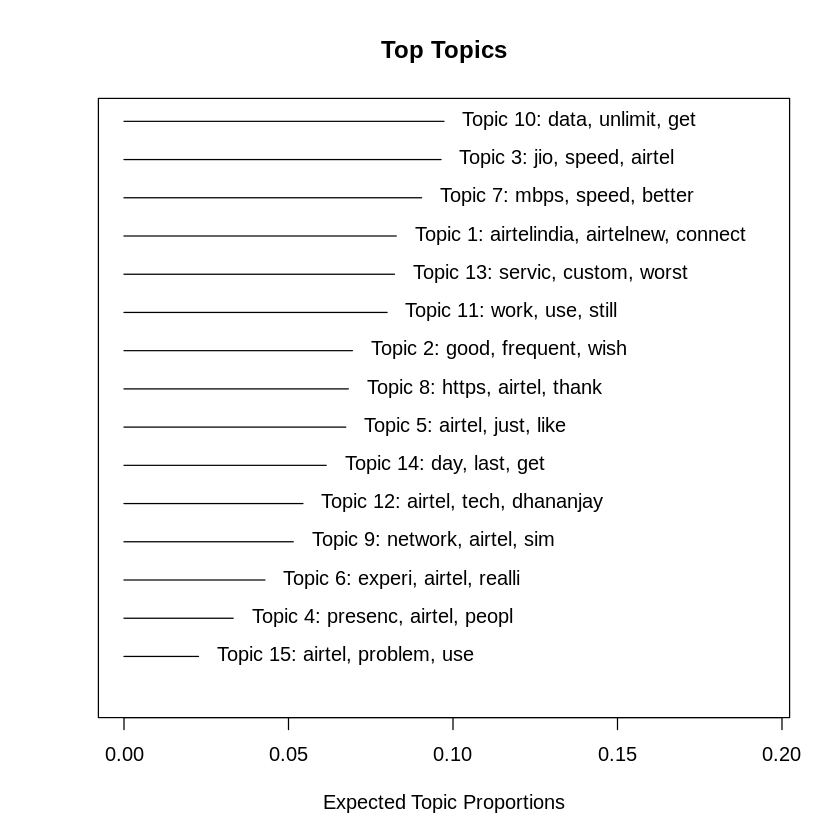

In [18]:
# Try with just 'company' as the prevalence variable
system.time({
  First_STM <- stm(docs, vocab, 15,
                   prevalence =~ Website,  # Use only one covariate for now
                   data = meta,
                   seed = 15, max.em.its = 5
  )
})

plot(First_STM)


   user  system elapsed 
 14.512   0.003  14.516 

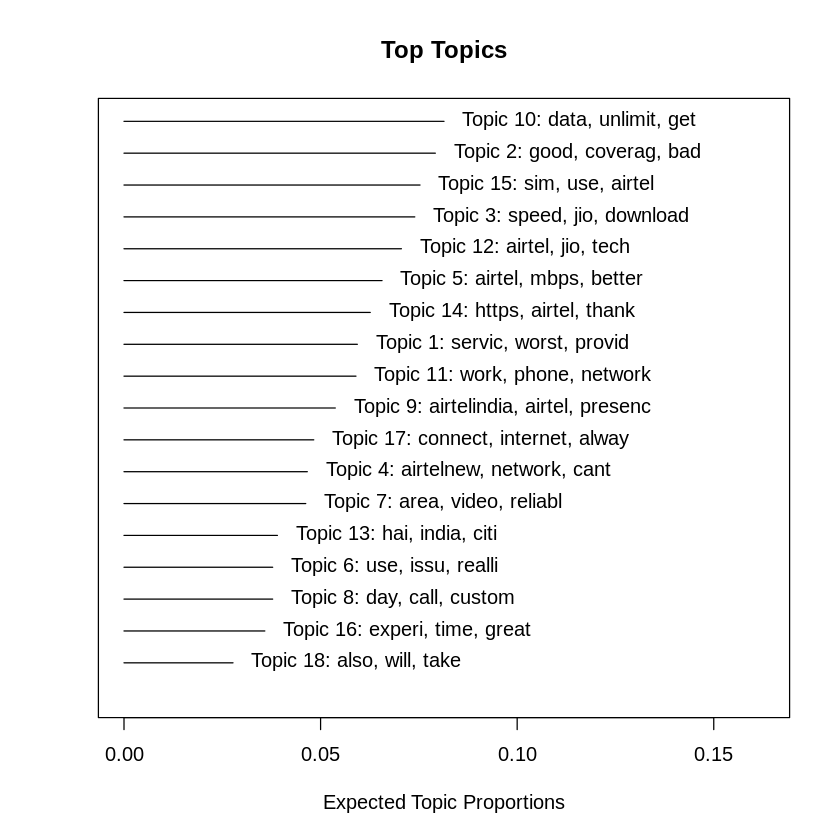

In [19]:
# Load required library
library(stm)

# Set seed for reproducibility
set.seed(832)

# Perform the second STM with 18 topics and a maximum of 75 EM iterations
system.time({
  Second_STM <- stm(documents = out$documents,
                    vocab = out$vocab,
                    K = 18,
                    prevalence =~  Website,  # Adjust this to match your actual data columns
                    max.em.its = 75,
                    data = out$meta,
                    init.type = "Spectral",
                    verbose = FALSE
  )
})

# Plot the second topic model
plot(Second_STM)


   user  system elapsed 
193.119   0.015 193.159 

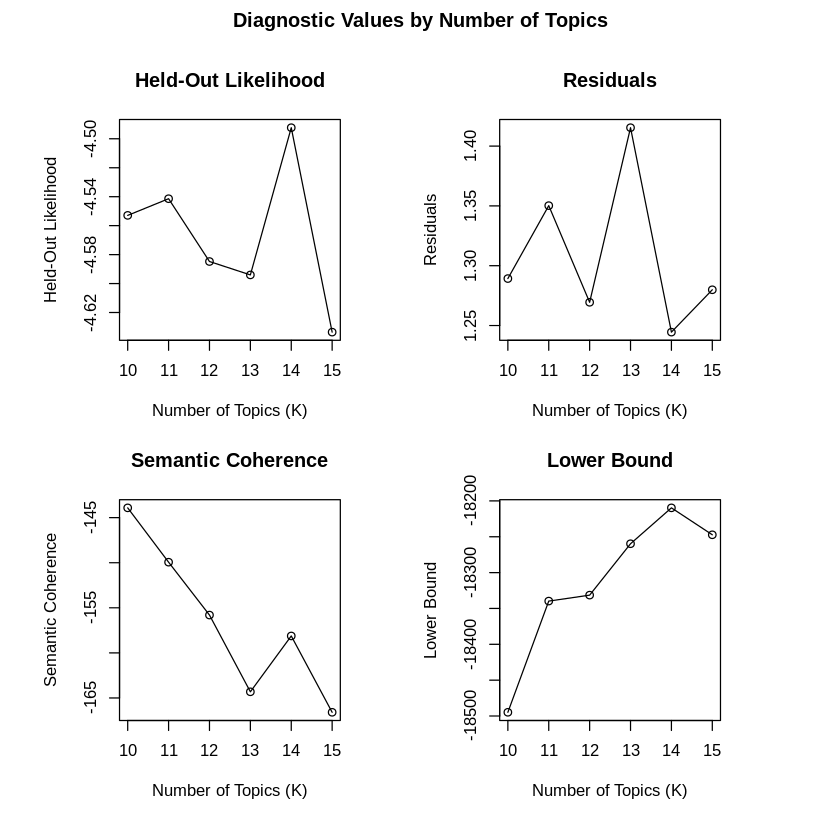

In [21]:
# Load required library
library(stm)

# Set seed for reproducibility
set.seed(833)

# Find the optimal number of topics from 10 to 30
system.time({
    findingk <- searchK(out$documents,
                         out$vocab,
                         K = 10:15,           # Range of topics to test
                         prevalence =~  Website, # Adjust to your metadata
                         data = out$meta,
                         verbose = FALSE
    )
})

# Plot the results to visualize the optimal k
plot(findingk)

Beginning Spectral Initialization 
	 Calculating the gram matrix...
	 Finding anchor words...
 	..........
	 Recovering initialization...
 	..
Initialization complete.
............................................................................................................
Completed E-Step (0 seconds). 
Completed M-Step. 
Completing Iteration 1 (approx. per word bound = -5.403) 
............................................................................................................
Completed E-Step (0 seconds). 
Completed M-Step. 
Completing Iteration 2 (approx. per word bound = -5.180, relative change = 4.132e-02) 
............................................................................................................
Completed E-Step (0 seconds). 
Completed M-Step. 
Completing Iteration 3 (approx. per word bound = -5.065, relative change = 2.210e-02) 
............................................................................................................
Completed E-St

   user  system elapsed 
185.230   0.744 185.999 

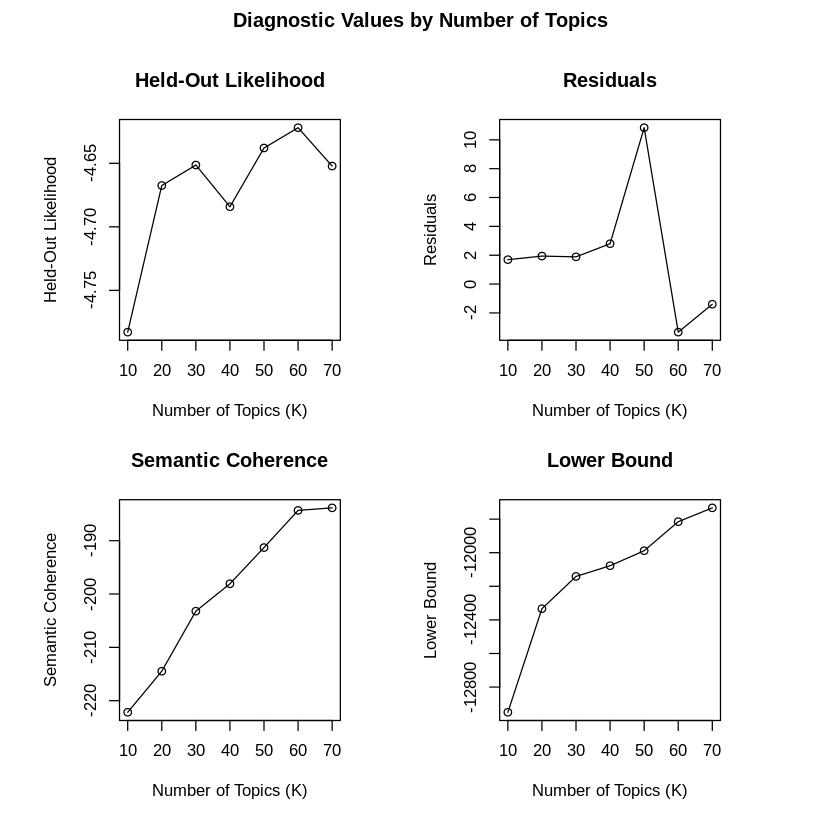

In [23]:
# Load required library
library(stm)

# Set seed for reproducibility
set.seed(834)

# Find the optimal number of topics with specific parameters
system.time({
    findingk_ver2 <- searchK(documents = out$documents,
                              vocab = out$vocab,
                              K = c(10, 20, 30, 40, 50, 60, 70), # Specify K to try
                              N = 500,  # Matches 10% of documents, adjust if needed
                              proportion = 0.5, # Default proportion of heldout data
                              heldout.seed = 1234, # Optional seed for reproducibility
                              M = 10, # Number of heldout iterations
                              cores = 1, # Number of cores to use (default = 1)
                              prevalence =~  Website, # Adjust based on your metadata
                              max.em.its = 75, # Maximum EM iterations
                              data = out$meta, # Metadata
                              init.type = "Spectral", # Initialization method
                              verbose = TRUE # Verbose output
    )
})

# Plot the results to visualize the optimal k
plot(findingk_ver2)


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘abind’, ‘magic’, ‘lpSolve’, ‘linprog’, ‘RcppProgress’




Beginning Spectral Initialization 
	 Calculating the gram matrix...
	 Finding anchor words...
 		 Initializing tSNE with PCA...
 		 Using tSNE to project to a low-dimensional space...
 		 Calculating exact convex hull...
 	
	 Recovering initialization...
 	..
Initialization complete.
............................................................................................................
Completed E-Step (0 seconds). 
Completed M-Step. 
Completing Iteration 1 (approx. per word bound = -5.107) 
............................................................................................................
Completed E-Step (0 seconds). 
Completed M-Step. 
Completing Iteration 2 (approx. per word bound = -4.795, relative change = 6.123e-02) 
............................................................................................................
Completed E-Step (0 seconds). 
Completed M-Step. 
Completing Iteration 3 (approx. per word bound = -4.678, relative change = 2.437e-02) 
......

   user  system elapsed 
 27.032   0.098  27.137 

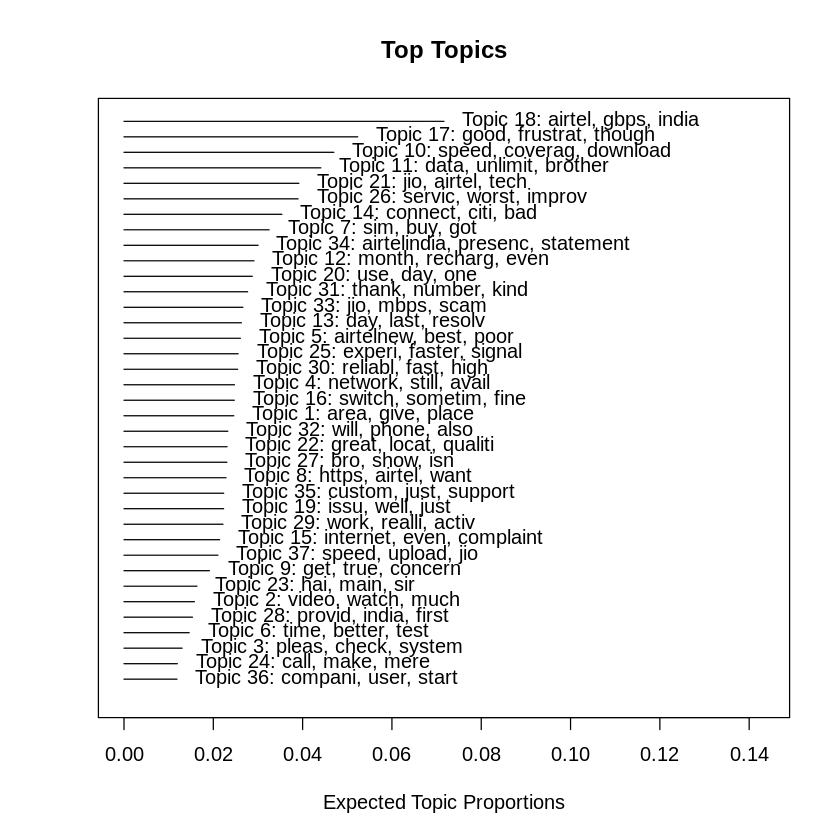

In [24]:
# Load required library
install.packages(c("Rtsne", "rsvd", "geometry"))
library(Rtsne)
library(rsvd)
library(geometry)
library(stm)

# Set seed for reproducibility
set.seed(835)

# Find the optimal number of topics using the Lee-Mimno method
system.time({
    findingk_ver3.lee_mimno <- stm(documents = out$documents,
                                    vocab = out$vocab,
                                    K = 0,  # K=0 to run the Lee-Mimno method
                                    seed = 1234,  # Seed for reproducibility
                                    prevalence =~  Website,  # Adjust this based on your metadata
                                    max.em.its = 75,  # Maximum EM iterations
                                    data = out$meta,  # Metadata
                                    init.type = "Spectral",  # Initialization method
                                    verbose = TRUE  # Verbose output
    )
})

# Plot the results to visualize the optimal k
plot(findingk_ver3.lee_mimno)


   user  system elapsed 
 15.815   0.002  15.819 

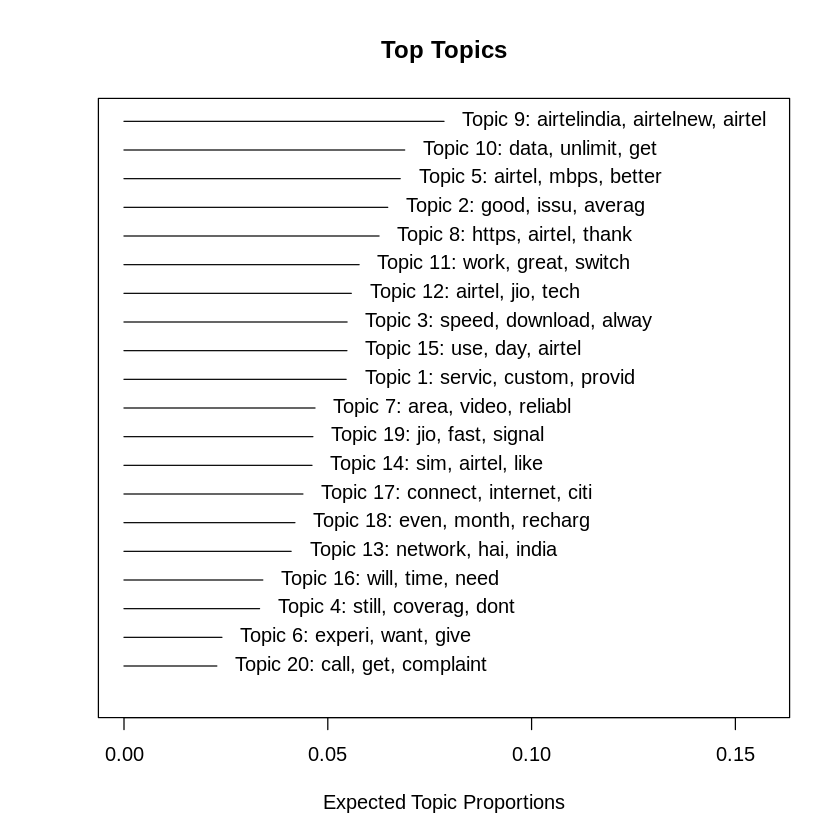

In [26]:
# Run final topic model at 20 topics and see how long it takes
set.seed(836)
system.time({
    Third_STM <- stm(documents = out$documents, vocab = out$vocab,
                  K = 20, prevalence =~  Website,
                  max.em.its = 75, data = out$meta,
                  init.type = "Spectral", verbose = FALSE
    )
})

#Plot
plot(Third_STM)

In [27]:
# Top Words
labelTopics(Third_STM)

Topic 1 Top Words:
 	 Highest Prob: servic, custom, provid, care, team, first, proper 
 	 FREX: care, custom, servic, often, proper, provid, team 
 	 Lift: care, often, proper, custom, servic, team, provid 
 	 Score: servic, often, custom, provid, care, team, proper 
Topic 2 Top Words:
 	 Highest Prob: good, issu, averag, frequent, realli, fast, without 
 	 FREX: good, frequent, averag, issu, realli, improv, know 
 	 Lift: frequent, good, averag, issu, realli, fast, without 
 	 Score: good, frequent, averag, issu, realli, fast, without 
Topic 3 Top Words:
 	 Highest Prob: speed, download, alway, test, consist, better, wish 
 	 FREX: download, speed, consist, alway, test, wish, better 
 	 Lift: download, consist, speed, wish, alway, test, improv 
 	 Score: consist, speed, download, better, alway, wish, upload 
Topic 4 Top Words:
 	 Highest Prob: still, coverag, dont, just, true, last, though 
 	 FREX: dont, coverag, still, true, though, happen, just 
 	 Lift: dont, happen, coverag, thou

In [28]:
# We can find the top documents associated with a topic with the findThoughts function:
# top 2 paragraps for Topic 1 to 10

findThoughts(Third_STM, texts = meta$Comment,n = 2, topics = 1:10)


 Topic 1: 
 	 @airtelindia Shameless cheaters. Your service is far from customer satisfaction.  Your system to interact with your customer service team is just eye wash. Complain lodged in your App is not looked into and closed at your end. I have enough evidence. Yet u claiming reputation!
 	@airtelnews Airtel also first service provider to start cheating its own customer 
 Topic 2: 
 	 Mostly good, but not without issues.
 	Coverage is frequently an issue. 
 Topic 3: 
 	 The download speeds are lightning-fast on 5G, but I wish the coverage was more consistent.
 	Download speeds are lightning-fast, but I wish the coverage was more consistent. 
 Topic 4: 
 	 @airtelnews 5g plus is not coming indoor but it is coming  outside
No 5g plus coverage in indoor
Please resolve, it 
No resolution after repeated complaints
*** NO REPLY IN DM ALSO,,, 
Porting is the only option available now.....
 	It was working fine last month, don't know what happened now  It’s just consuming data. It seems Ai

In [29]:
# We can look at multiple, or all, topics this way as well.
# For this we’ll just look at the shorttext.
# top 3 paragraps for Topic #1 to 15
# We can find the top documents associated with a topic with the findThoughts function:

findThoughts(Third_STM, texts = meta$Comment,n = 3, topics = 1:15)


 Topic 1: 
 	 @airtelindia Shameless cheaters. Your service is far from customer satisfaction.  Your system to interact with your customer service team is just eye wash. Complain lodged in your App is not looked into and closed at your end. I have enough evidence. Yet u claiming reputation!
 	@airtelnews Airtel also first service provider to start cheating its own customer
 	Service is often slow. 
 Topic 2: 
 	 Mostly good, but not without issues.
 	Coverage is frequently an issue.
 	Frequently unreliable. 
 Topic 3: 
 	 The download speeds are lightning-fast on 5G, but I wish the coverage was more consistent.
 	Download speeds are lightning-fast, but I wish the coverage was more consistent.
 	I was test the speed test today at 8AM.
From jio- 670Mb download and 47Mb upload.

From Airtel - 243Mb download and 0.97 Mb upload (very bad upload speed in Airtel) 
 Topic 4: 
 	 @airtelnews 5g plus is not coming indoor but it is coming  outside
No 5g plus coverage in indoor
Please resolve, it

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




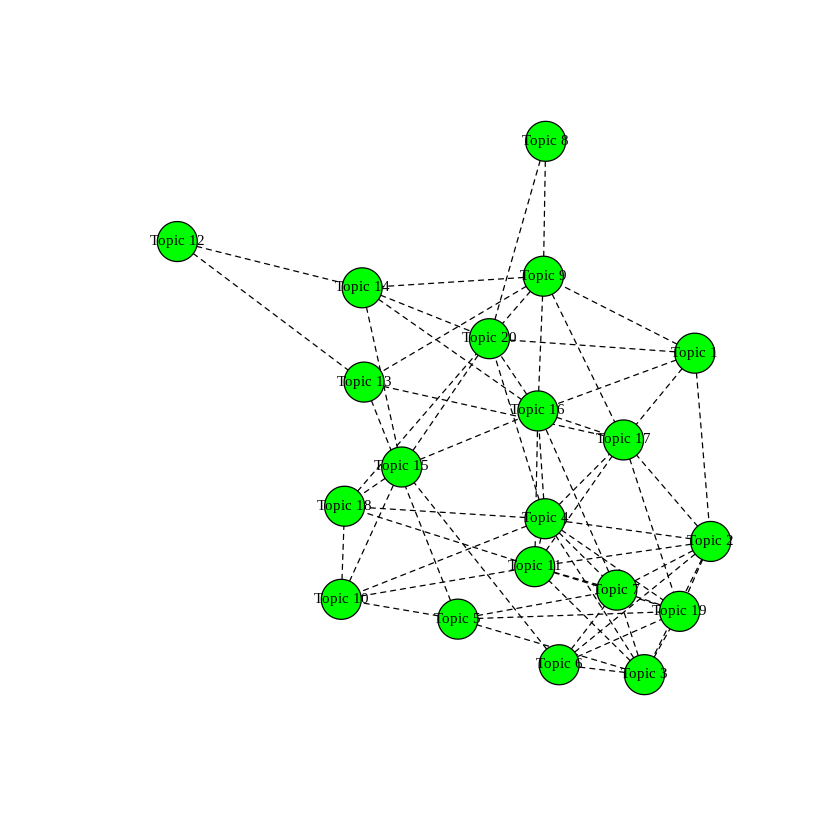

In [30]:

# Graphical display of topic correlations
install.packages("igraph")
library(igraph)

topic_correlation<-topicCorr(Third_STM)
plot(topic_correlation)

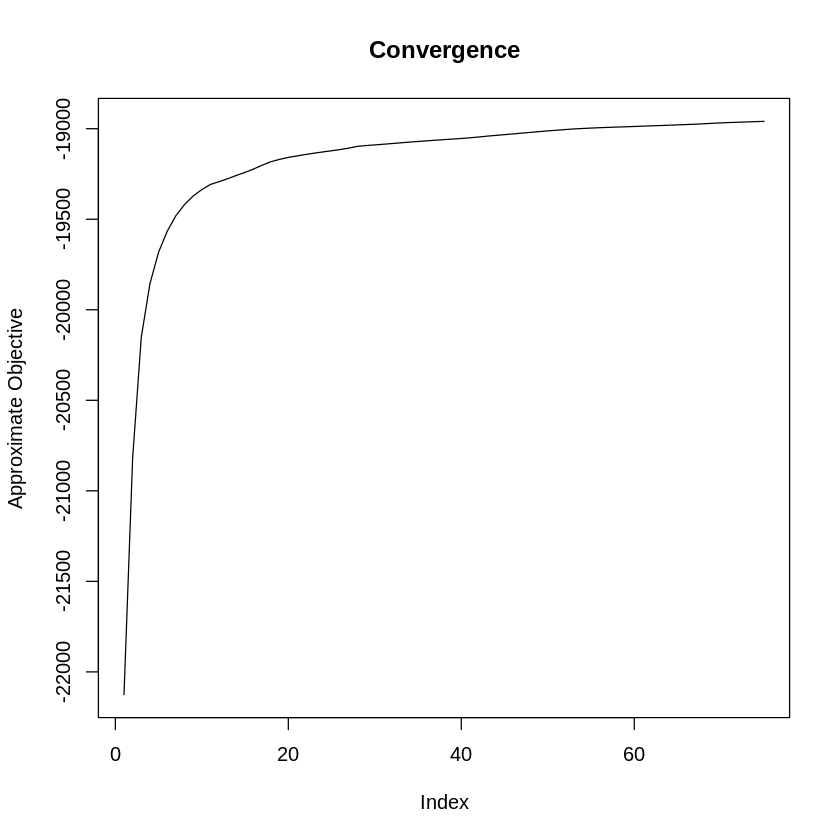

In [31]:
# Graphical display of convergence


plot(Third_STM$convergence$bound, type = "l",
         ylab = "Approximate Objective",
         main = "Convergence")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: RColorBrewer



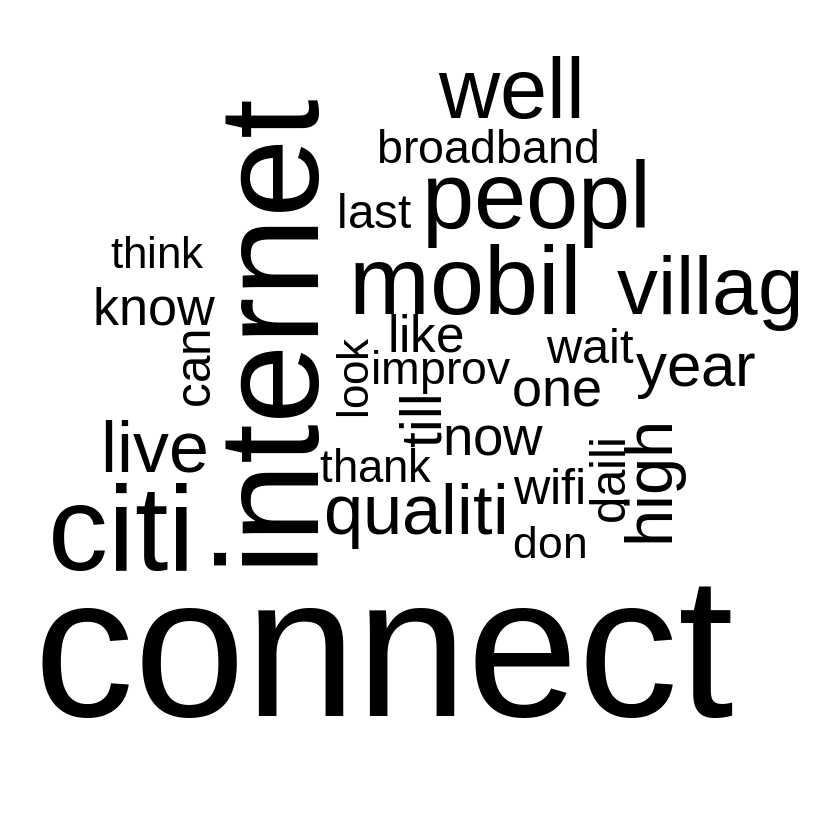

In [32]:

# Wordcloud:topic 17 with word distribution
install.packages("wordcloud")
library(wordcloud)

set.seed(837)
cloud(Third_STM, topic=17, scale=c(10,2))

In [33]:
print(Third_STM$settings$dim$K)


[1] 20


In [36]:


predict_topics <- estimateEffect(
  formula = 1:10 ~ Website,  # Using 'Website' for now
  stmobj = Third_STM,        # Ensure 'Third_STM' exists
  metadata = out$meta,
  uncertainty = "Global"
)


In [37]:


str(predict_topics)

List of 8
 $ parameters :List of 10
  ..$ :List of 25
  .. ..$ :List of 2
  .. .. ..$ est : Named num [1:4] 0.00646 0.09158 0.06611 0.01145
  .. .. .. ..- attr(*, "names")= chr [1:4] "(Intercept)" "Websitesurvey" "Websitetwitter" "Websiteyoutube"
  .. .. ..$ vcov: num [1:4, 1:4] 0.000118 -0.000118 -0.000118 -0.000118 -0.000118 ...
  .. ..$ :List of 2
  .. .. ..$ est : Named num [1:4] 0.00995 0.07482 0.06205 0.00683
  .. .. .. ..- attr(*, "names")= chr [1:4] "(Intercept)" "Websitesurvey" "Websitetwitter" "Websiteyoutube"
  .. .. ..$ vcov: num [1:4, 1:4] 0.000111 -0.000111 -0.000111 -0.000111 -0.000111 ...
  .. ..$ :List of 2
  .. .. ..$ est : Named num [1:4] 0.01245 0.08217 0.06525 0.00953
  .. .. .. ..- attr(*, "names")= chr [1:4] "(Intercept)" "Websitesurvey" "Websitetwitter" "Websiteyoutube"
  .. .. ..$ vcov: num [1:4, 1:4] 0.000148 -0.000148 -0.000148 -0.000148 -0.000148 ...
  .. ..$ :List of 2
  .. .. ..$ est : Named num [1:4] 0.00916 0.07178 0.06714 0.00883
  .. .. .. ..- attr(*, 

[1] "X"         "Comment"   "Website"   "Sentiment" "company"  


[1] "instagram" "survey"    "twitter"   "youtube"

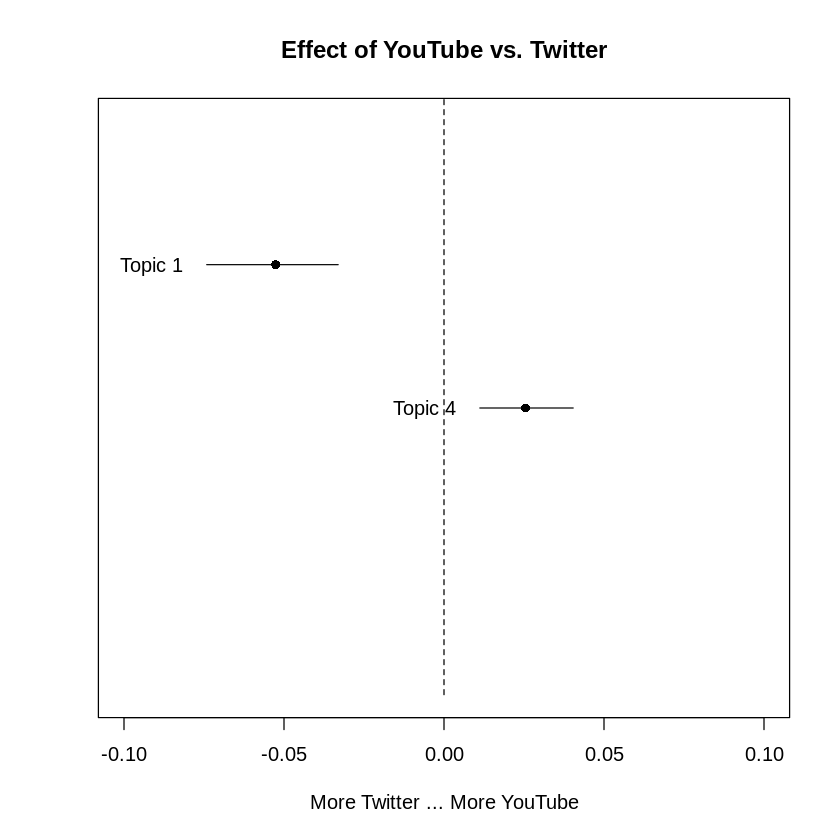

In [38]:



# Check metadata column names


print(names(out$meta))

# Ensure 'Website' is a factor
out$meta$Website <- as.factor(out$meta$Website)

# Estimate effect of 'Website' covariate on topics
predict_topics <- estimateEffect(formula = 1:10 ~ Website,   # Only 'Website' is used
                                 stmobj = Third_STM,
                                 metadata = out$meta,
                                 uncertainty = "Global",
                                 prior = 1e-5)

# Check levels of 'Website' to ensure valid covariate values
levels(out$meta$Website)

# Set seed for reproducibility
set.seed(837)

# Plot the effect of 'Website' covariate on selected topics
plot(predict_topics,
     covariate = "Website",
     topics = c(1, 4, 10),              # Topics of interest
     model = Third_STM,
     method = "difference",
     cov.value1 = "youtube",           # Change to actual levels in your data
     cov.value2 = "twitter",           # Compare two levels in 'Website'
     xlab = "More Twitter ... More YouTube",
     main = "Effect of YouTube vs. Twitter",
     xlim = c(-0.1, 0.1),
     labeltype = "custom",
     custom.labels = c('Topic 1', 'Topic 4', 'Topic 10'))


[1] "instagram" "survey"    "twitter"   "youtube"

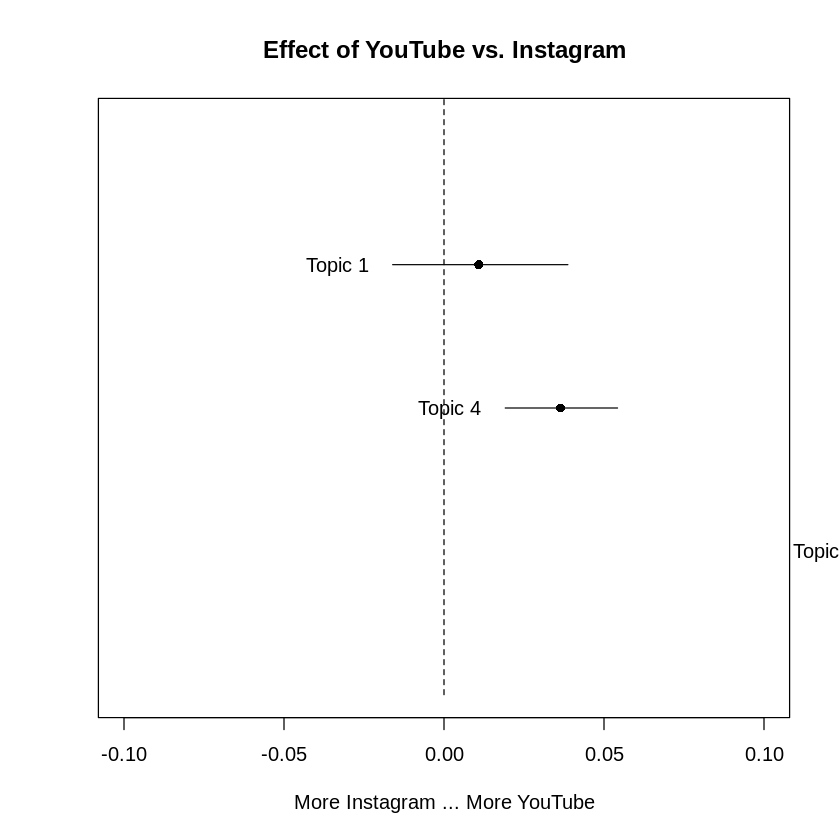

In [39]:







# Check the levels of the 'Website' variable
levels(out$meta$Website)  # Ensure 'youtube' and 'instagram' are valid levels

# Ensure the covariate values are valid levels
set.seed(837)
plot(predict_topics,
     covariate = "Website",            # Focus on 'Website' covariate
     topics = c(1, 4, 10),             # Topics of interest
     model = Third_STM,
     method = "difference",
     cov.value1 = "youtube",           # Compare 'YouTube'
     cov.value2 = "instagram",         # With 'Instagram'
     xlab = "More Instagram ... More YouTube",
     main = "Effect of YouTube vs. Instagram",   # Updated plot title
     xlim = c(-0.1, 0.1),
     labeltype = "custom",
     custom.labels = c('Topic 1', 'Topic 4', 'Topic 10'))


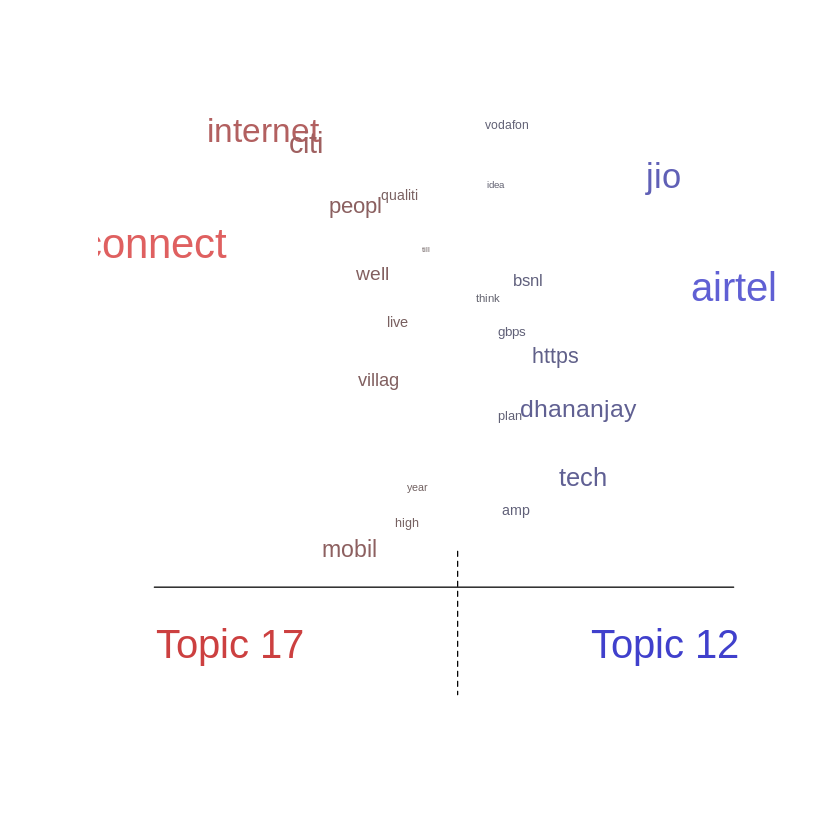

In [40]:

set.seed(831)
plot(Third_STM,
     type="perspectives",
     topics=c(17,12),
     plabels = c("Topic 17","Topic 12"))

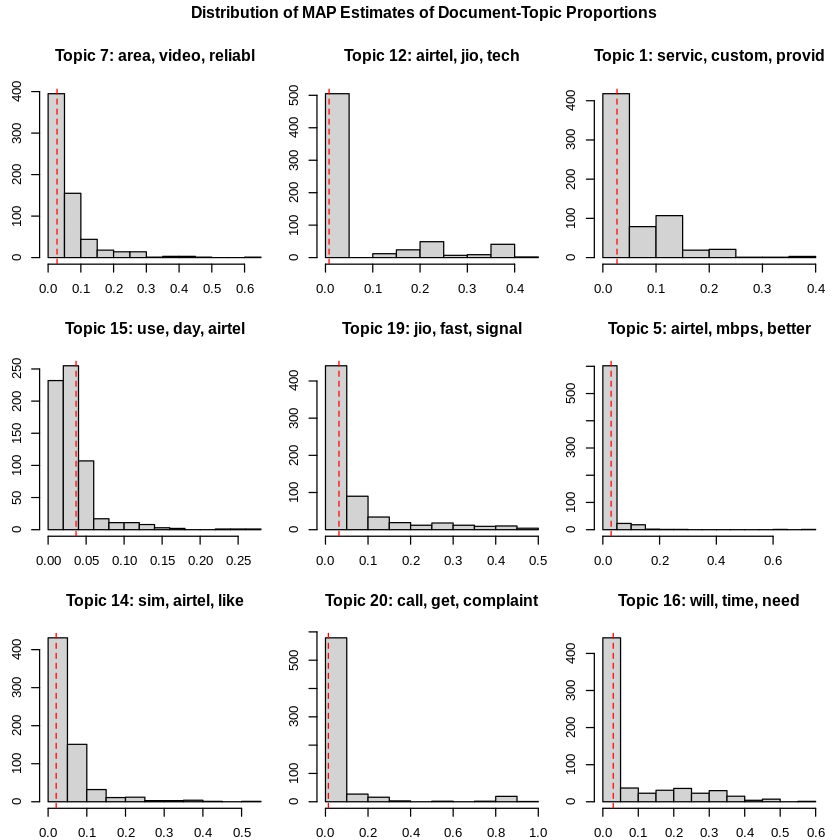

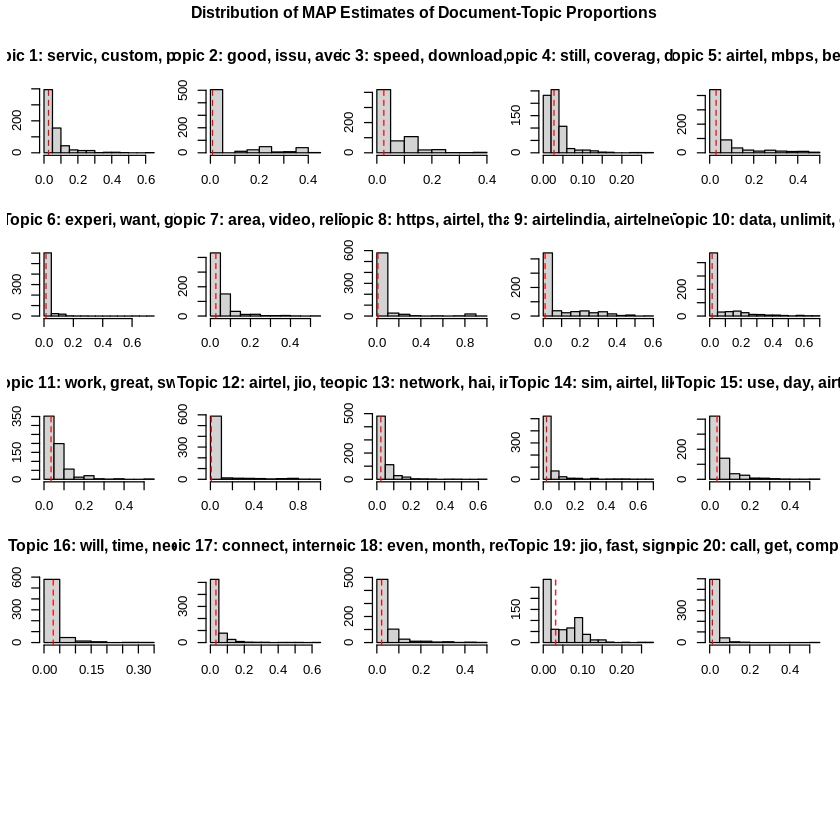

In [41]:

print(Third_STM$settings$dim$K)



predict_topics <- estimateEffect(
  formula = 1:10 ~ Website,  # Using 'Website' for now
  stmobj = Third_STM,        # Ensure 'Third_STM' exists
  metadata = out$meta,
  uncertainty = "Global"
)





# Topic proportions

plot(Third_STM, type = "hist", topics = sample(1:20, size = 9))
plot(Third_STM, type="hist")

 [1] -177.33529 -229.85860 -205.21618 -179.17463 -210.41409 -156.32213
 [7] -183.84360  -61.92985 -125.95971 -161.18518 -229.22296 -160.26759
[13] -214.78948 -146.16788 -156.29585 -193.97939 -149.31566 -163.77176
[19] -238.58286 -141.46940
 [1] 9.788862 9.792564 9.792461 9.785496 9.792337 9.752914 9.779296 9.553398
 [9] 9.716490 9.775484 9.772645 9.646046 9.785904 9.556799 9.678963 9.785711
[17] 9.792024 9.683763 9.792319 9.785527


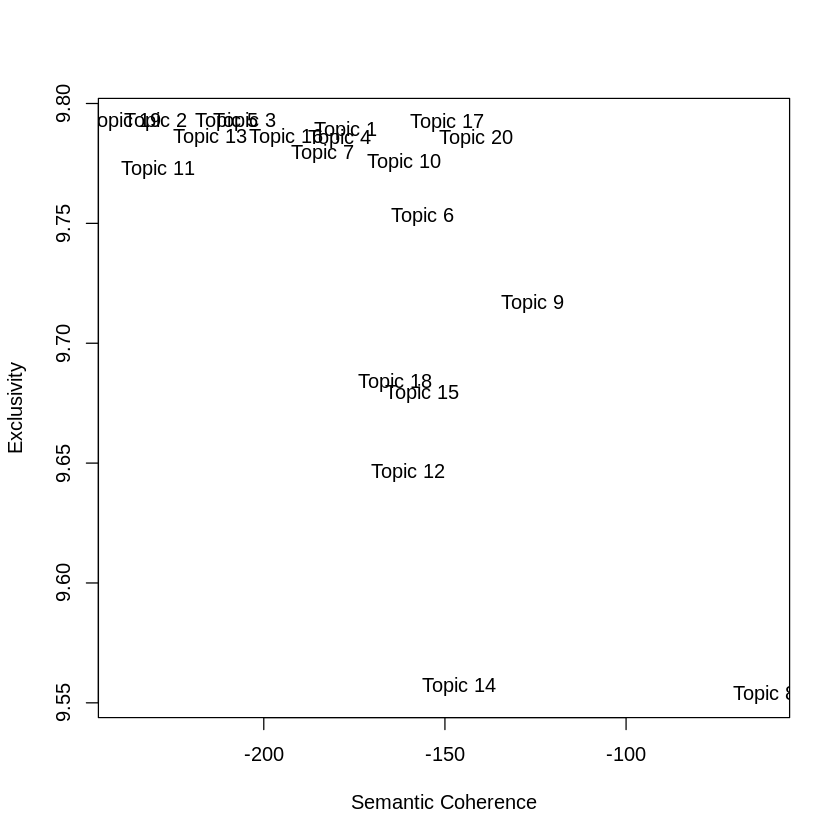

In [42]:


# The topicQuality() function plots these values
# and labels each with its topic number:

topicQuality(model=Third_STM, documents=docs)

# JIO OUTPUTS BELOW

In [43]:
# Clear up data in global environment
rm(list=ls())

# Load data from csv file
df <- read.csv("Jio_Comments.csv")

# Check for NAs
sapply(df, function(x) sum(is.na(x)))

# Overview of original dataset
str(df)
sapply(df, typeof)


X   Comment   Website Sentiment   Company 
        0         0         0         0         0

'data.frame':	721 obs. of  5 variables:
 $ X        : int  0 1 2 3 4 5 6 7 8 9 ...
 $ Comment  : chr  "I think you don’t follow the latest trends. I live in a Tier 2 city and have had fiber connectivity here for th"| __truncated__ "It would be great if they offered an unlimited 5G plan." "5G is not fully ready, but it’s ready to be fast.  I haven't received it in my area yet" "I left my 30Mbps Jio Fiber WiFi to use Jio 5G." ...
 $ Website  : chr  "youtube" "youtube" "youtube" "youtube" ...
 $ Sentiment: int  1 -1 -1 1 1 1 -1 -1 1 1 ...
 $ Company  : chr  "Jio" "Jio" "Jio" "Jio" ...


X     Comment     Website   Sentiment     Company 
  "integer" "character" "character"   "integer" "character"

In [44]:

df[sample(nrow(df), 10), ]

,X,Comment,Website,Sentiment,Company
,<int>,<chr>,<chr>,<int>,<chr>
452,451,@JioCare I am looking for new connection,twitter,-1,Jio
437,436,"@bhadana_ki27449 Hi Kishor, that’s not the experience we aim for.​ Please DM us your JioFiber I'd or the registered mobile number to assist you further - Priyalaxmi https://t.co/3LgXqjD03v",twitter,-1,Jio
130,129,Does everyone get 1.5 GB in Jio?,youtube,1,Jio
262,261,Ericsson and Jio showcases 5G use cases for India https://t.co/7kOXXkywg9 https://t.co/dMqLxuXXvg,twitter,-1,Jio
523,522,"@JioCare You guys are focusing on installation. But not on the service. When i have asked for an installation, you guys came within hours. And i promoted jio to install for other 5 accounts. But now for service its already been 5 days. No single update regarding the resolution.",twitter,-1,Jio
629,628,"Reliable, but not always the fastest.",survey,1,Jio
257,256,jio 5g with 1.5 gbps,instagram,-1,Jio
379,378,"@reliancejio @KKRiders advertising unlimited data after booking 1000 gb data ,then after getting connection only 130 gb https://t.co/Ly5yS50XhN",twitter,-1,Jio
491,490,@reliancejio @mipaltan Really worst service...i have been following up with the issue of my air fiber for the past 4 days. There is support from local customer service and even after raising a support case. Appointment has scheduled for today 11.00 AM. even after that there is no response. SR0000212FBS,twitter,-1,Jio


In [45]:
# Install necessary packages if not already installed
install.packages("stm")
install.packages("tm")
install.packages("SnowballC")

# Load required libraries
library(tm)
library(SnowballC)
library(stm)

# Load the dataset
df <- read.csv("Jio_Comments.csv")

# Perform text processing on the 'Comment' column
processed <- textProcessor(df$Comment, metadata = df,
                           lowercase = TRUE,           # Convert to lowercase
                           removestopwords = TRUE,     # Remove stop words
                           removenumbers = TRUE,       # Remove numbers
                           removepunctuation = TRUE,   # Remove punctuation
                           stem = TRUE,                # Apply stemming
                           wordLengths = c(3, Inf),    # Keep words of length 3 or more
                           sparselevel = 1,            # Keep all words (no sparsity cutoff)
                           language = "en",            # English language
                           verbose = TRUE,             # Display detailed output
                           onlycharacter = TRUE,       # Keep only alphabetic characters
                           striphtml = FALSE,          # Do not remove HTML tags (no HTML in the data)
                           customstopwords = NULL,     # No custom stopwords
                           v1 = FALSE)                 # Use the default version of textProcessor

# Output the result of the text processing
str(processed)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Building corpus... 
Converting to Lower Case... 
Removing punctuation... 
Removing stopwords... 
Removing numbers... 
Stemming... 
Creating Output... 
List of 4
 $ documents   :List of 719
  ..$ 1  : int [1:2, 1:15] 261 1 358 2 532 1 617 1 635 1 ...
  ..$ 2  : int [1:2, 1:4] 699 1 1130 1 1204 1 1658 1
  ..$ 3  : int [1:2, 1:7] 98 1 609 1 654 1 727 1 1286 2 ...
  ..$ 4  : int [1:2, 1:6] 617 1 842 2 942 1 1025 1 1674 1 ...
  ..$ 5  : int [1:2, 1:6] 476 1 589 1 1107 1 1511 1 1735 1 ...
  ..$ 6  : int [1:2, 1:21] 10 1 14 1 194 1 358 1 405 1 ...
  ..$ 7  : int [1:2, 1:6] 121 1 142 1 576 1 767 1 1174 1 ...
  ..$ 8  : int [1:2, 1:9] 139 1 335 1 345 1 500 1 842 2 ...
  ..$ 9  : int [1:2, 1:21] 128 1 499 1 500 1 529 1 676 3 ...
  ..$ 10 : int [1:2, 1:10] 121 1 128 1 221 1 1060 2 1102 1 ...
  ..$ 11 : int [1:2, 1:6] 128 1 335 1 630 1 1062 1 1642 1 ...
  ..$ 12 : int [1:2, 1:6] 49 1 209 1 652 1 842 1 1290 1 ...
  ..$ 13 : int [1:2, 1:23] 59 1 98 1 104 1 206 1 676 1 ...
  ..$ 14 : int [1:2, 1:5] 2

In [46]:
# Load required library
library(stm)

# Assuming 'df' is already loaded and 'processed' contains the text processed data
# If not, load the data and process it using textProcessor as described earlier

# Filter out terms that don’t appear in more than 10 documents
out <- prepDocuments(processed$documents, processed$vocab, processed$meta, lower.thresh=5)

# Extract documents, vocab, and metadata after filtering
docs <- out$documents
vocab <- out$vocab
meta <- out$meta



Removing 1692 of 1949 terms (2709 of 7120 tokens) due to frequency 
Removing 11 Documents with No Words 
Your corpus now has 708 documents, 257 terms and 4411 tokens.

In [48]:
str(meta)
# Convert 'Website' and 'company' to factors if they are not already
meta$Website <- as.factor(meta$Website)

# Check levels of categorical variables in 'meta'
# Assuming 'Website' and 'company' are the categorical variables
levels(meta$Website)


'data.frame':	708 obs. of  5 variables:
 $ X        : int  0 1 2 3 4 5 6 7 8 9 ...
 $ Comment  : chr  "I think you don’t follow the latest trends. I live in a Tier 2 city and have had fiber connectivity here for th"| __truncated__ "It would be great if they offered an unlimited 5G plan." "5G is not fully ready, but it’s ready to be fast.  I haven't received it in my area yet" "I left my 30Mbps Jio Fiber WiFi to use Jio 5G." ...
 $ Website  : Factor w/ 4 levels "instagram","survey",..: 4 4 4 4 4 4 4 4 4 4 ...
 $ Sentiment: int  1 -1 -1 1 1 1 -1 -1 1 1 ...
 $ Company  : chr  "Jio" "Jio" "Jio" "Jio" ...


[1] "instagram" "survey"    "twitter"   "youtube"

Beginning Spectral Initialization 
	 Calculating the gram matrix...
	 Finding anchor words...
 	...............
	 Recovering initialization...
 	..
Initialization complete.
.....................................................................................................
Completed E-Step (0 seconds). 
Completed M-Step. 
Completing Iteration 1 (approx. per word bound = -5.341) 
.....................................................................................................
Completed E-Step (0 seconds). 
Completed M-Step. 
Completing Iteration 2 (approx. per word bound = -5.056, relative change = 5.337e-02) 
.....................................................................................................
Completed E-Step (0 seconds). 
Completed M-Step. 
Completing Iteration 3 (approx. per word bound = -4.882, relative change = 3.434e-02) 
.....................................................................................................
Completed E-Step (0 seconds). 
Comple

   user  system elapsed 
  1.637   0.021   1.658 

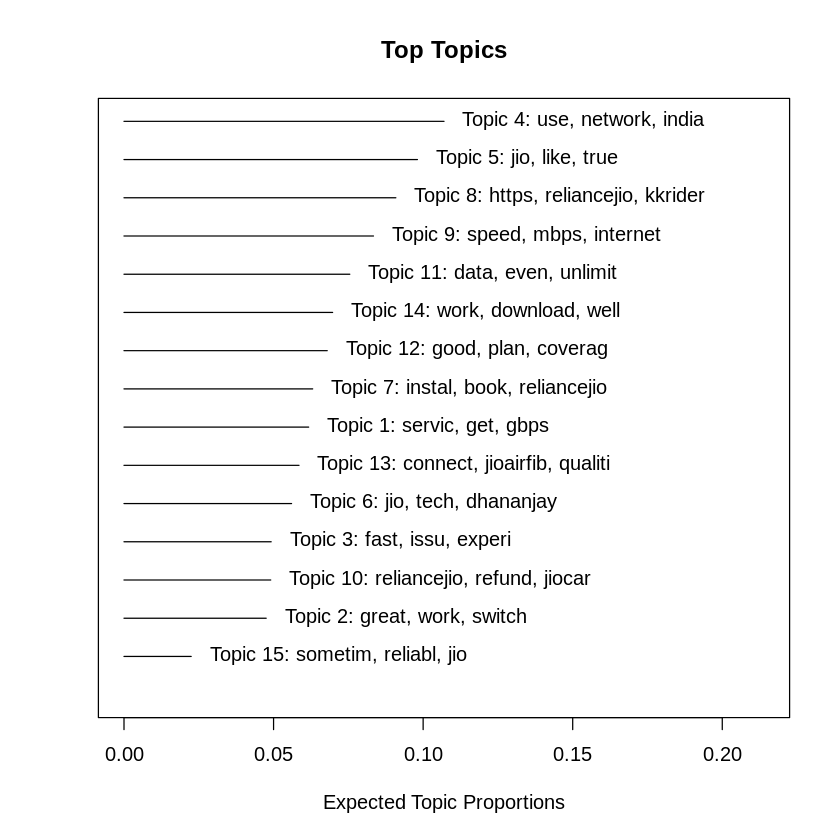

In [49]:
# Try with just 'company' as the prevalence variable
system.time({
  First_STM <- stm(docs, vocab, 15,
                   prevalence =~ Website,  # Use only one covariate for now
                   data = meta,
                   seed = 15, max.em.its = 5
  )
})

plot(First_STM)


   user  system elapsed 
 16.440   0.015  16.458 

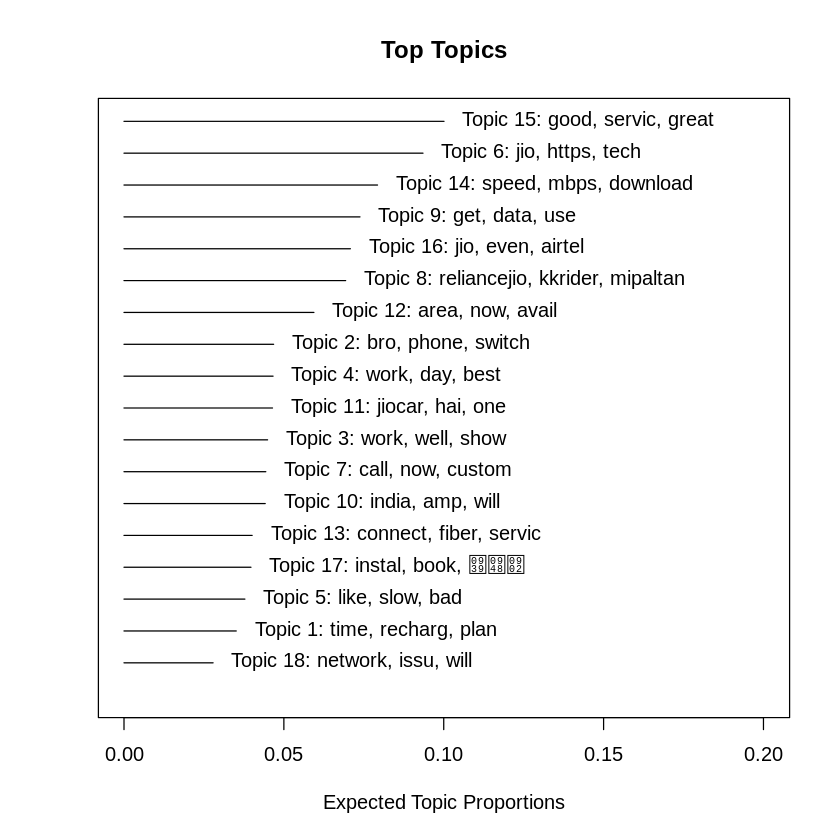

In [50]:
# Load required library
library(stm)

# Set seed for reproducibility
set.seed(832)

# Perform the second STM with 18 topics and a maximum of 75 EM iterations
system.time({
  Second_STM <- stm(documents = out$documents,
                    vocab = out$vocab,
                    K = 18,
                    prevalence =~  Website,  # Adjust this to match your actual data columns
                    max.em.its = 75,
                    data = out$meta,
                    init.type = "Spectral",
                    verbose = FALSE
  )
})

# Plot the second topic model
plot(Second_STM)


   user  system elapsed 
227.012   0.034 227.080 

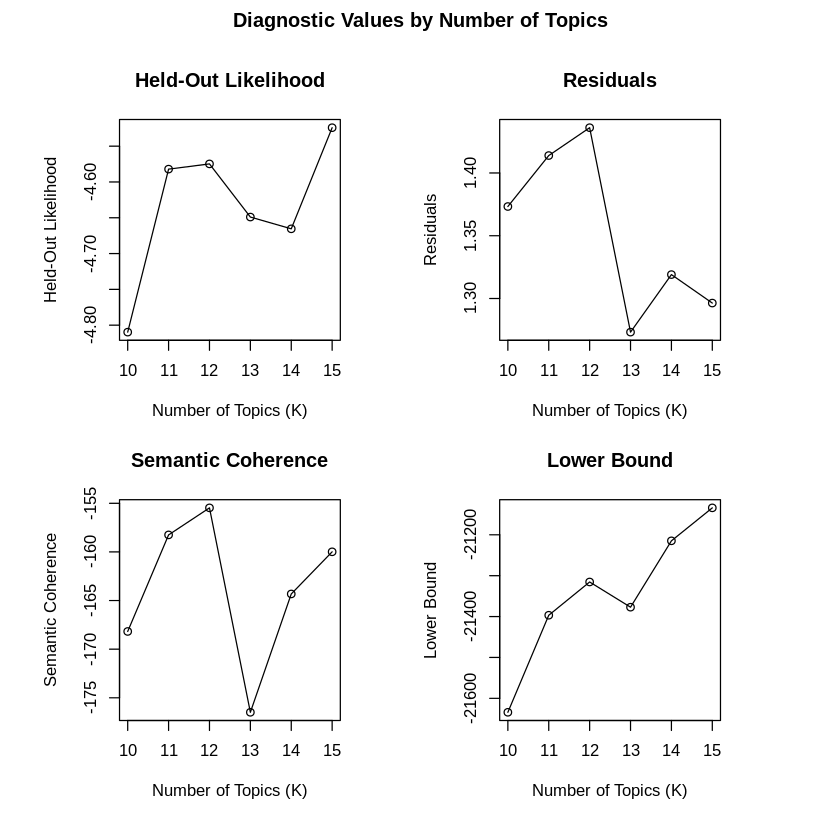

In [51]:
# Load required library
library(stm)

# Set seed for reproducibility
set.seed(833)

# Find the optimal number of topics from 10 to 30
system.time({
    findingk <- searchK(out$documents,
                         out$vocab,
                         K = 10:15,           # Range of topics to test
                         prevalence =~  Website, # Adjust to your metadata
                         data = out$meta,
                         verbose = FALSE
    )
})

# Plot the results to visualize the optimal k
plot(findingk)

Beginning Spectral Initialization 
	 Calculating the gram matrix...
	 Finding anchor words...
 	..........
	 Recovering initialization...
 	..
Initialization complete.
.....................................................................................................
Completed E-Step (0 seconds). 
Completed M-Step. 
Completing Iteration 1 (approx. per word bound = -5.700) 
.....................................................................................................
Completed E-Step (0 seconds). 
Completed M-Step. 
Completing Iteration 2 (approx. per word bound = -5.310, relative change = 6.839e-02) 
.....................................................................................................
Completed E-Step (0 seconds). 
Completed M-Step. 
Completing Iteration 3 (approx. per word bound = -5.165, relative change = 2.744e-02) 
.....................................................................................................
Completed E-Step (0 seconds). 
Completed M

   user  system elapsed 
206.093   0.703 206.824 

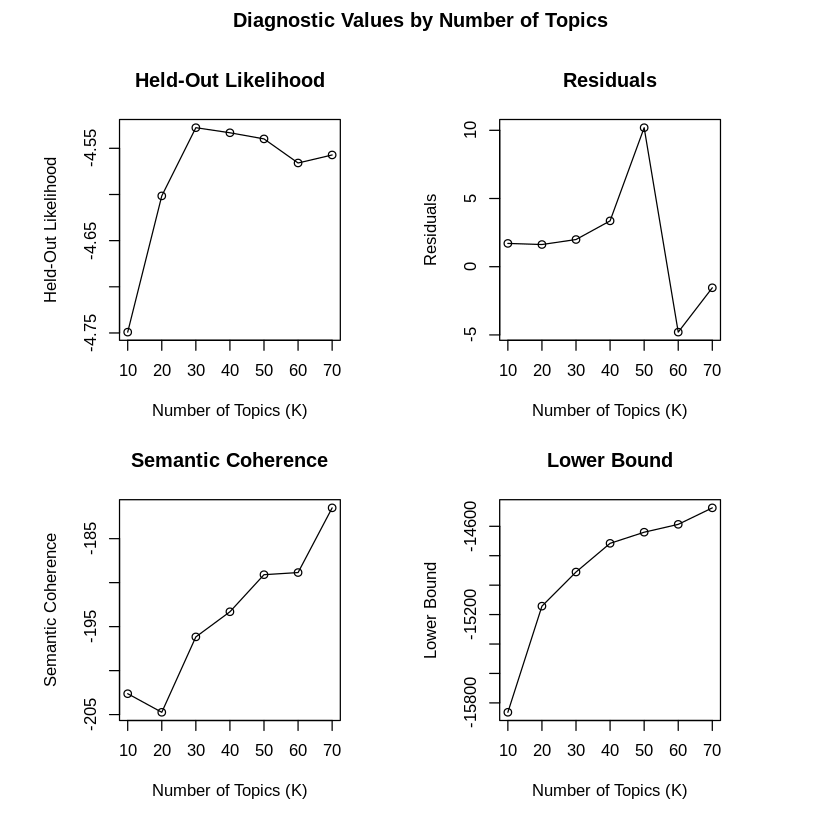

In [52]:
# Load required library
library(stm)

# Set seed for reproducibility
set.seed(834)

# Find the optimal number of topics with specific parameters
system.time({
    findingk_ver2 <- searchK(documents = out$documents,
                              vocab = out$vocab,
                              K = c(10, 20, 30, 40, 50, 60, 70), # Specify K to try
                              N = 500,  # Matches 10% of documents, adjust if needed
                              proportion = 0.5, # Default proportion of heldout data
                              heldout.seed = 1234, # Optional seed for reproducibility
                              M = 10, # Number of heldout iterations
                              cores = 1, # Number of cores to use (default = 1)
                              prevalence =~  Website, # Adjust based on your metadata
                              max.em.its = 75, # Maximum EM iterations
                              data = out$meta, # Metadata
                              init.type = "Spectral", # Initialization method
                              verbose = TRUE # Verbose output
    )
})

# Plot the results to visualize the optimal k
plot(findingk_ver2)


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Beginning Spectral Initialization 
	 Calculating the gram matrix...
	 Finding anchor words...
 		 Initializing tSNE with PCA...
 		 Using tSNE to project to a low-dimensional space...
 		 Calculating exact convex hull...
 	
	 Recovering initialization...
 	..
Initialization complete.
.....................................................................................................
Completed E-Step (0 seconds). 
Completed M-Step. 
Completing Iteration 1 (approx. per word bound = -5.205) 
.....................................................................................................
Completed E-Step (0 seconds). 
Completed M-Step. 
Completing Iteration 2 (approx. per word bound = -4.874, relative change = 6.366e-02) 
.....................................................................................................
Completed E-Step (0 seconds). 
Completed M-Step. 
Completing Iteration 3 (approx. per word bound = -4.743, relative change = 2.693e-02) 
...........................

   user  system elapsed 
 34.910   0.119  35.033 

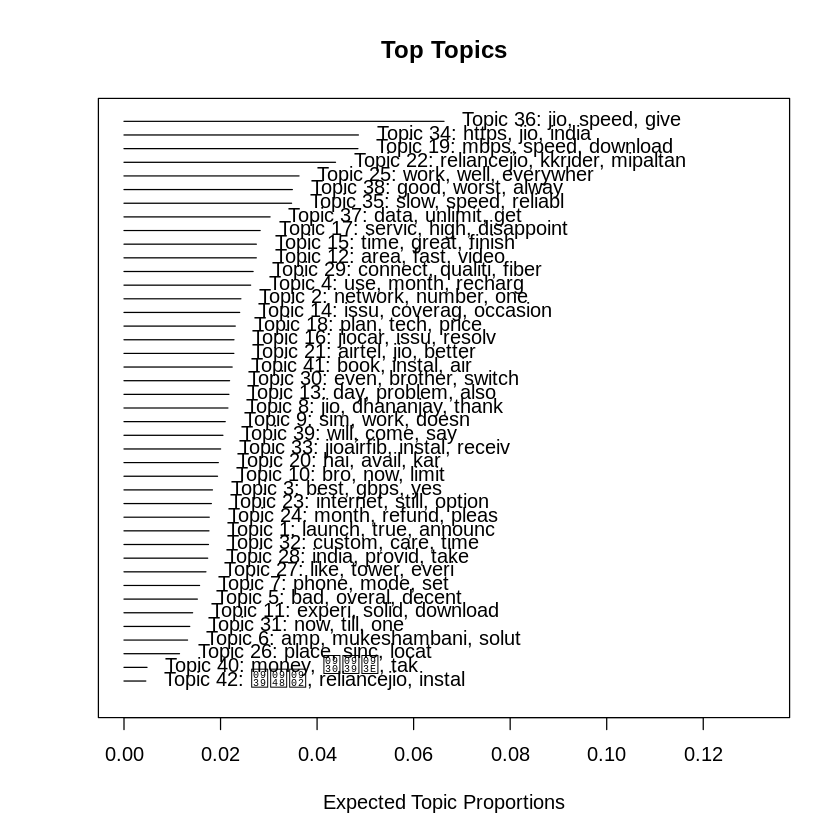

In [53]:
# Load required library
install.packages(c("Rtsne", "rsvd", "geometry"))
library(Rtsne)
library(rsvd)
library(geometry)
library(stm)

# Set seed for reproducibility
set.seed(835)

# Find the optimal number of topics using the Lee-Mimno method
system.time({
    findingk_ver3.lee_mimno <- stm(documents = out$documents,
                                    vocab = out$vocab,
                                    K = 0,  # K=0 to run the Lee-Mimno method
                                    seed = 1234,  # Seed for reproducibility
                                    prevalence =~  Website,  # Adjust this based on your metadata
                                    max.em.its = 75,  # Maximum EM iterations
                                    data = out$meta,  # Metadata
                                    init.type = "Spectral",  # Initialization method
                                    verbose = TRUE  # Verbose output
    )
})

# Plot the results to visualize the optimal k
plot(findingk_ver3.lee_mimno)


   user  system elapsed 
 16.806   0.001  16.810 

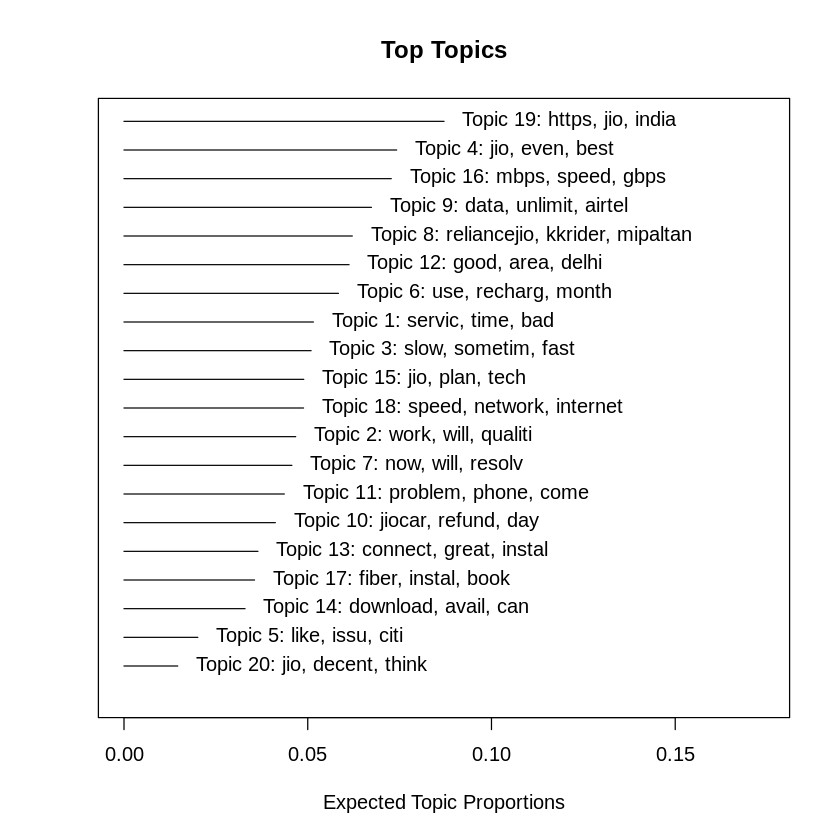

In [54]:
# Run final topic model at 20 topics and see how long it takes
set.seed(836)
system.time({
    Third_STM <- stm(documents = out$documents, vocab = out$vocab,
                  K = 20, prevalence =~  Website,
                  max.em.its = 75, data = out$meta,
                  init.type = "Spectral", verbose = FALSE
    )
})

#Plot
plot(Third_STM)

In [55]:
# We can look at multiple, or all, topics this way as well.
# For this we’ll just look at the shorttext.
# top 3 paragraps for Topic #1 to 15
# We can find the top documents associated with a topic with the findThoughts function:
# top 2 paragraps for Topic 1 to 10

# Top Words
labelTopics(Third_STM)

Topic 1 Top Words:
 	 Highest Prob: servic, time, bad, perform, poor, general, better 
 	 FREX: servic, perform, bad, general, time, poor, oper 
 	 Lift: general, perform, servic, bad, poor, time, oper 
 	 Score: servic, perform, general, time, bad, poor, better 
Topic 2 Top Words:
 	 Highest Prob: work, will, qualiti, bsnl, soon, fine, villag 
 	 FREX: work, bsnl, soon, fine, qualiti, will, villag 
 	 Lift: fine, soon, bsnl, thing, work, villag, qualiti 
 	 Score: fine, work, qualiti, will, bsnl, soon, thing 
Topic 3 Top Words:
 	 Highest Prob: slow, sometim, fast, coverag, though, high, video 
 	 FREX: slow, sometim, fast, though, coverag, everywher, high 
 	 Lift: sometim, fast, though, everywher, slow, high, coverag 
 	 Score: fast, everywher, sometim, slow, coverag, though, enough 
Topic 4 Top Words:
 	 Highest Prob: jio, even, best, get, now, sim, india 
 	 FREX: even, best, sim, jio, now, proper, get 
 	 Lift: best, even, slower, sim, port, jio, proper 
 	 Score: best, jio, even

In [56]:

findThoughts(Third_STM, texts = meta$Comment,n = 2, topics = 1:10)


 Topic 1: 
 	 Service quality is poor.
 	Service quality is disappointing. 
 Topic 2: 
 	 Everything works fine near the 5G tower, but as soon as I go to a crowded area, both 5G and 4G turn into 2G.
 	It should be a 5G+ network, or it won’t work. Switch to Jio; it will work. 
 Topic 3: 
 	 Sometimes my 5G runs slow, sometimes 4G runs slow, and sometimes the internet just doesn’t work at all. If you call customer care to fix 5G, then 4G doesn’t work, and if you call for 4G, then 5G doesn’t work
 	Fast enough, but coverage varies. 
 Topic 4: 
 	 Jio is the best SIM.
 	This is why I’m porting my SIM to Jio  
 Topic 5: 
 	 Excellent most of the time, but occasional issues when traveling
 	Jio has no issues like that. 
 Topic 6: 
 	 Then I’m lucky; with a ₹395 recharge, I’m using unlimited 5G for 84 days. I used 320 GB data last month by using a hotspot on my laptop, and 200 GB so far this month (I live in Ghaziabad)."
 	Pretty solid, but could use improvement. 
 Topic 7: 
 	 @anjanikantba

In [57]:

findThoughts(Third_STM, texts = meta$Comment,n = 3, topics = 1:15)


 Topic 1: 
 	 Service quality is poor.
 	Service quality is disappointing.
 	Not bad, but slow at times. 
 Topic 2: 
 	 Everything works fine near the 5G tower, but as soon as I go to a crowded area, both 5G and 4G turn into 2G.
 	It should be a 5G+ network, or it won’t work. Switch to Jio; it will work.
 	Same thing is happening to me with my A34; even 4G+ doesn’t work properly. 
 Topic 3: 
 	 Sometimes my 5G runs slow, sometimes 4G runs slow, and sometimes the internet just doesn’t work at all. If you call customer care to fix 5G, then 4G doesn’t work, and if you call for 4G, then 5G doesn’t work
 	Fast enough, but coverage varies.
 	When I play games with more than 30+ FPS, my Jio 5G network switches to 4G... and sometimes the 5G speed is so slow that YouTube, Instagram, and other apps don't load, and sometimes there's no internet at all. 
 Topic 4: 
 	 Jio is the best SIM.
 	This is why I’m porting my SIM to Jio 
 	Jio best 
 Topic 5: 
 	 Excellent most of the time, but occasional

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



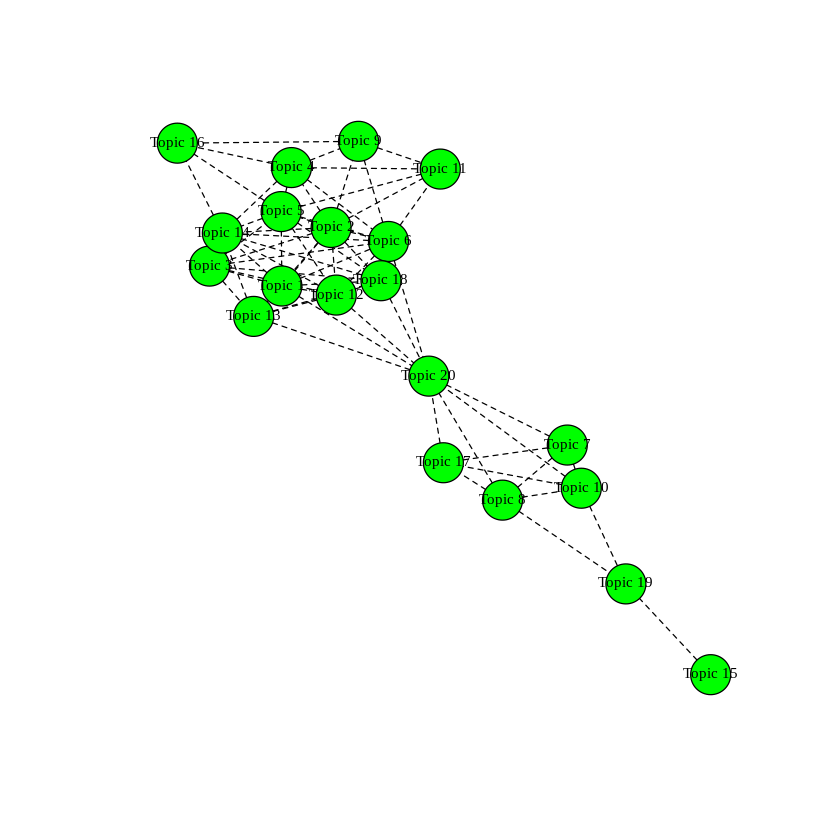

In [58]:
# Graphical display of convergence


# Graphical display of topic correlations
install.packages("igraph")
library(igraph)

topic_correlation<-topicCorr(Third_STM)
plot(topic_correlation)



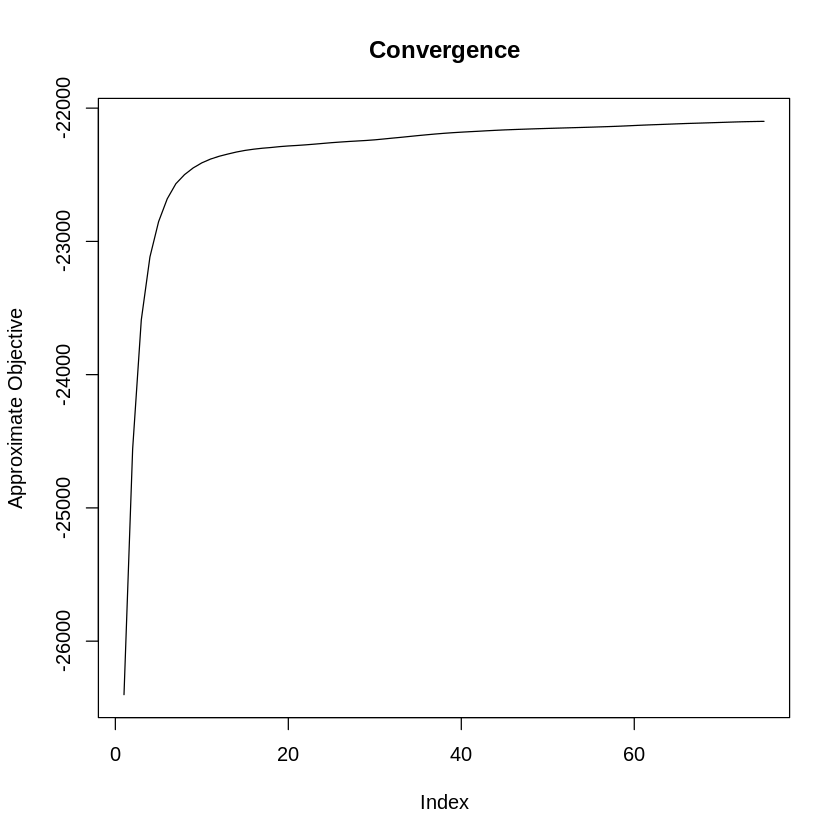

In [59]:
plot(Third_STM$convergence$bound, type = "l",
         ylab = "Approximate Objective",
         main = "Convergence")



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message in wordcloud::wordcloud(words = vocab, freq = vec, max.words = max.words, :
“fiber could not be fit on page. It will not be plotted.”


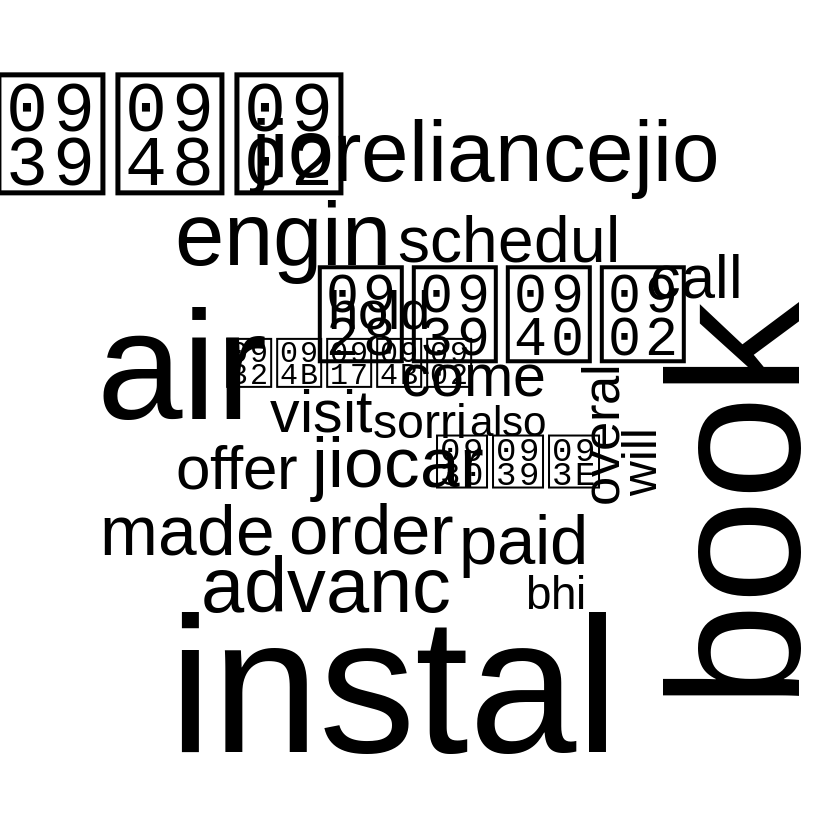

In [60]:

# Wordcloud:topic 17 with word distribution
install.packages("wordcloud")
library(wordcloud)

set.seed(837)
cloud(Third_STM, topic=17, scale=c(10,2))

In [61]:

print(Third_STM$settings$dim$K)



[1] 20


In [62]:


predict_topics <- estimateEffect(
  formula = 1:10 ~ Website,  # Using 'Website' for now
  stmobj = Third_STM,        # Ensure 'Third_STM' exists
  metadata = out$meta,
  uncertainty = "Global"
)


str(predict_topics)



List of 8
 $ parameters :List of 10
  ..$ :List of 25
  .. ..$ :List of 2
  .. .. ..$ est : Named num [1:4] 0.002882 0.154168 0.022502 0.000313
  .. .. .. ..- attr(*, "names")= chr [1:4] "(Intercept)" "Websitesurvey" "Websitetwitter" "Websiteyoutube"
  .. .. ..$ vcov: num [1:4, 1:4] 0.000102 -0.000102 -0.000102 -0.000102 -0.000102 ...
  .. ..$ :List of 2
  .. .. ..$ est : Named num [1:4] 0.003409 0.146028 0.021796 -0.000466
  .. .. .. ..- attr(*, "names")= chr [1:4] "(Intercept)" "Websitesurvey" "Websitetwitter" "Websiteyoutube"
  .. .. ..$ vcov: num [1:4, 1:4] 8.27e-05 -8.27e-05 -8.27e-05 -8.27e-05 -8.27e-05 ...
  .. ..$ :List of 2
  .. .. ..$ est : Named num [1:4] 0.00459 0.13686 0.02425 -0.00153
  .. .. .. ..- attr(*, "names")= chr [1:4] "(Intercept)" "Websitesurvey" "Websitetwitter" "Websiteyoutube"
  .. .. ..$ vcov: num [1:4, 1:4] 8.99e-05 -8.99e-05 -8.99e-05 -8.99e-05 -8.99e-05 ...
  .. ..$ :List of 2
  .. .. ..$ est : Named num [1:4] 0.002503 0.150871 0.024331 0.000488
  .. .. .

In [63]:

# Check metadata column names


print(names(out$meta))


[1] "X"         "Comment"   "Website"   "Sentiment" "Company"  


[1] "instagram" "survey"    "twitter"   "youtube"

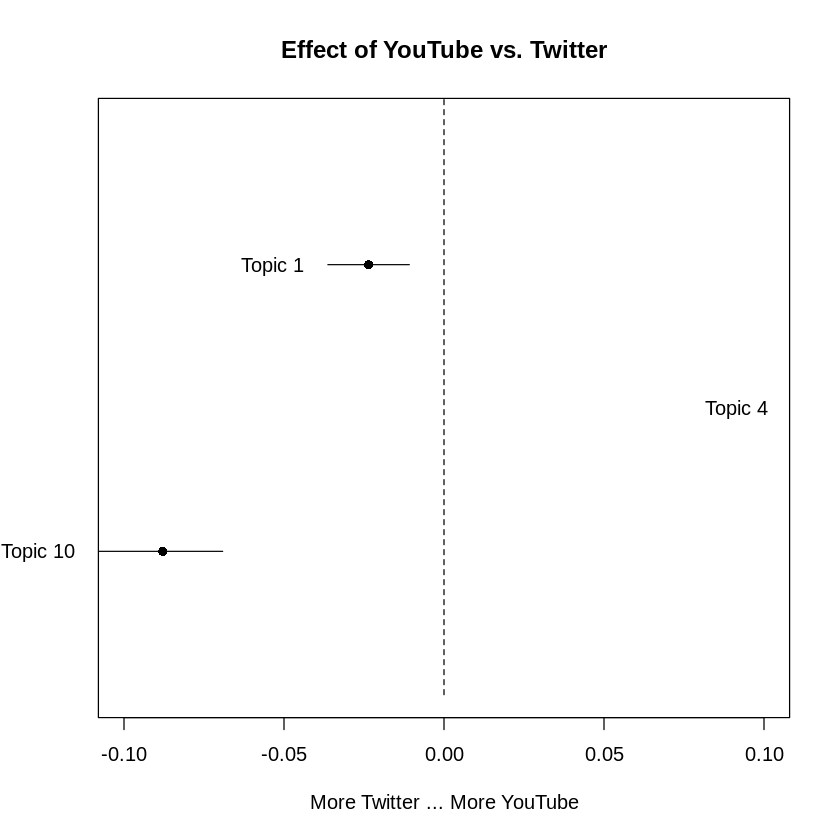

In [64]:

# Ensure 'Website' is a factor
out$meta$Website <- as.factor(out$meta$Website)

# Estimate effect of 'Website' covariate on topics
predict_topics <- estimateEffect(formula = 1:10 ~ Website,   # Only 'Website' is used
                                 stmobj = Third_STM,
                                 metadata = out$meta,
                                 uncertainty = "Global",
                                 prior = 1e-5)

# Check levels of 'Website' to ensure valid covariate values
levels(out$meta$Website)

# Set seed for reproducibility
set.seed(837)

# Plot the effect of 'Website' covariate on selected topics
plot(predict_topics,
     covariate = "Website",
     topics = c(1, 4, 10),              # Topics of interest
     model = Third_STM,
     method = "difference",
     cov.value1 = "youtube",           # Change to actual levels in your data
     cov.value2 = "twitter",           # Compare two levels in 'Website'
     xlab = "More Twitter ... More YouTube",
     main = "Effect of YouTube vs. Twitter",
     xlim = c(-0.1, 0.1),
     labeltype = "custom",
     custom.labels = c('Topic 1', 'Topic 4', 'Topic 10'))





[1] "instagram" "survey"    "twitter"   "youtube"

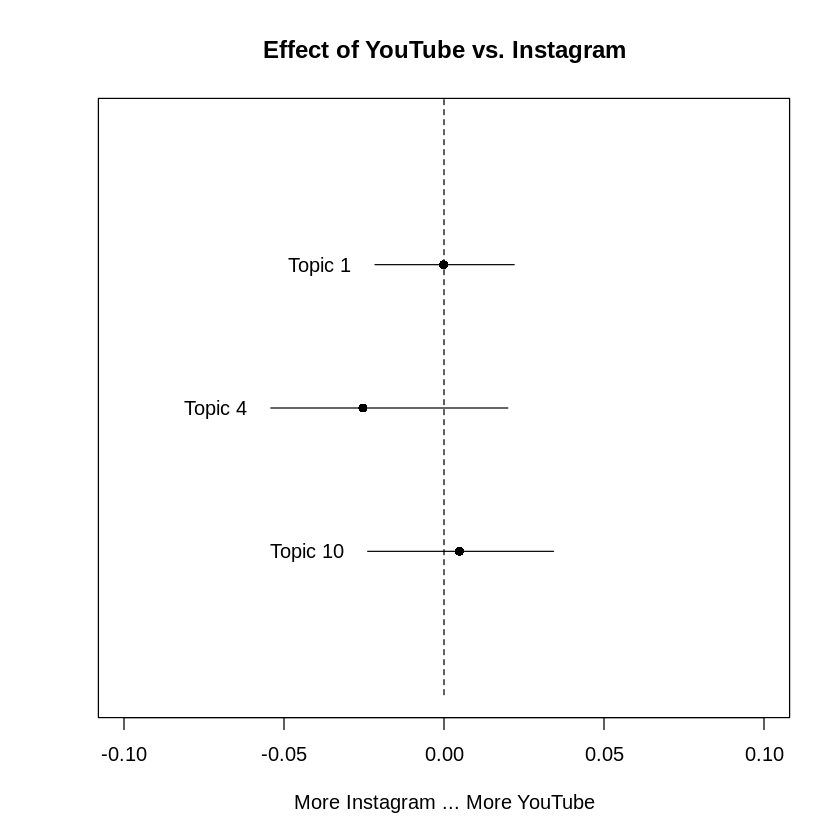

In [65]:



# Check the levels of the 'Website' variable
levels(out$meta$Website)  # Ensure 'youtube' and 'instagram' are valid levels

# Ensure the covariate values are valid levels
set.seed(837)
plot(predict_topics,
     covariate = "Website",            # Focus on 'Website' covariate
     topics = c(1, 4, 10),             # Topics of interest
     model = Third_STM,
     method = "difference",
     cov.value1 = "youtube",           # Compare 'YouTube'
     cov.value2 = "instagram",         # With 'Instagram'
     xlab = "More Instagram ... More YouTube",
     main = "Effect of YouTube vs. Instagram",   # Updated plot title
     xlim = c(-0.1, 0.1),
     labeltype = "custom",
     custom.labels = c('Topic 1', 'Topic 4', 'Topic 10'))




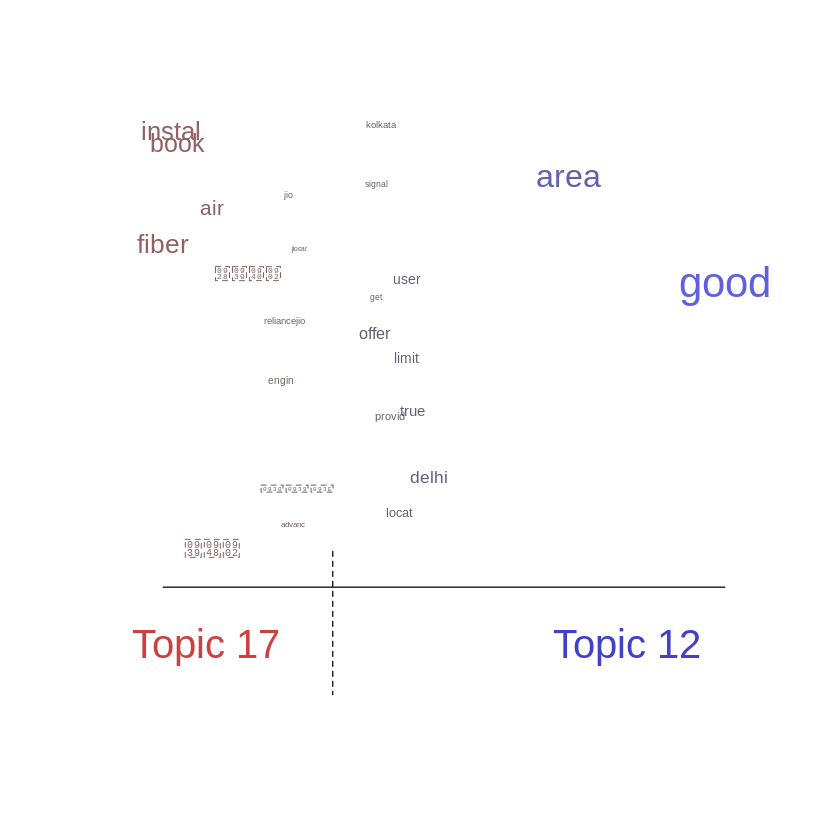

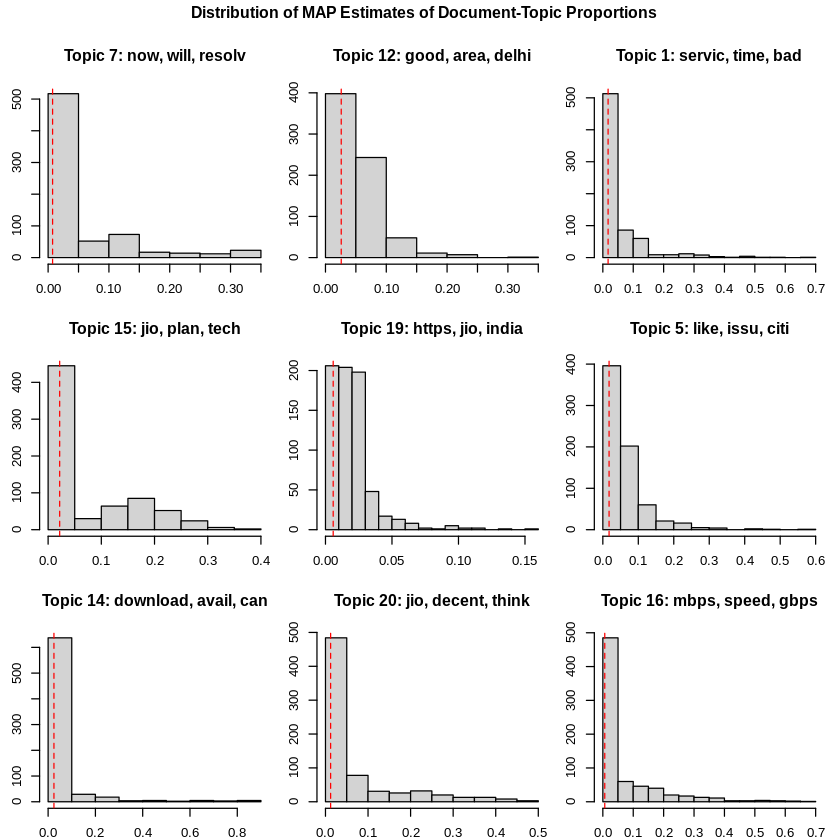

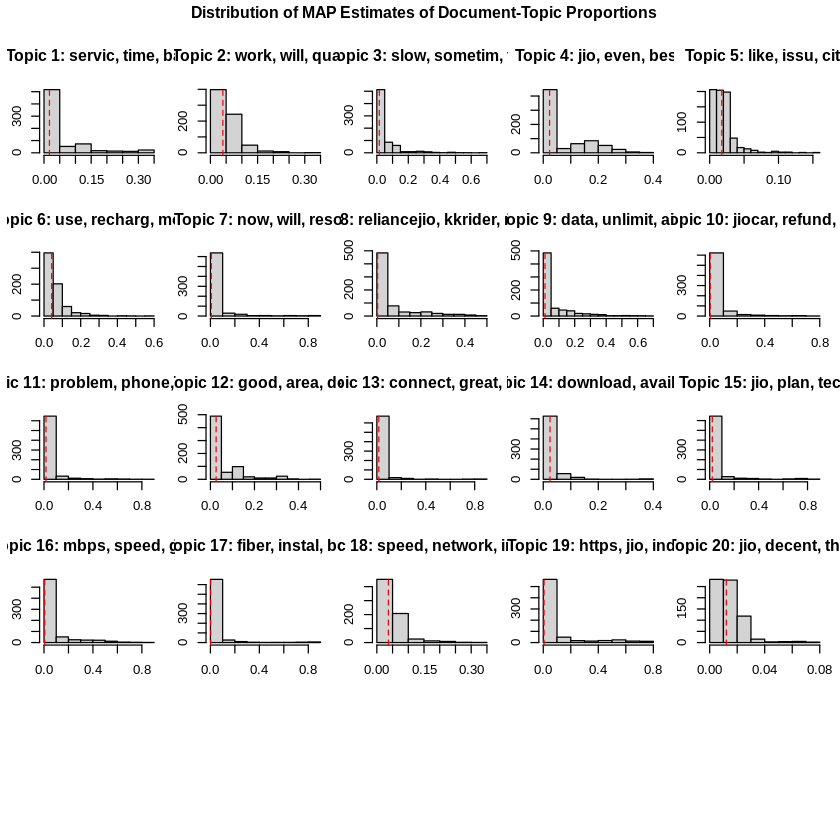

In [66]:
set.seed(831)
plot(Third_STM,
     type="perspectives",
     topics=c(17,12),
     plabels = c("Topic 17","Topic 12"))









# Topic proportions

plot(Third_STM, type = "hist", topics = sample(1:20, size = 9))
plot(Third_STM, type="hist")


 [1] -261.8488 -233.7679 -227.7054 -182.9759 -257.4459 -221.3015 -122.0171
 [8] -169.9658 -158.0332 -121.3032 -146.7701 -194.9329 -143.3248 -218.6351
[15] -160.3222 -162.6768 -111.7638 -206.7242 -160.4880 -224.9106
 [1] 9.824685 9.821581 9.824728 9.802647 9.824805 9.786120 9.426683 9.755366
 [9] 9.703314 9.629927 9.641590 9.813634 9.691495 9.818575 9.741084 9.716028
[17] 9.697233 9.791640 9.650409 9.822130


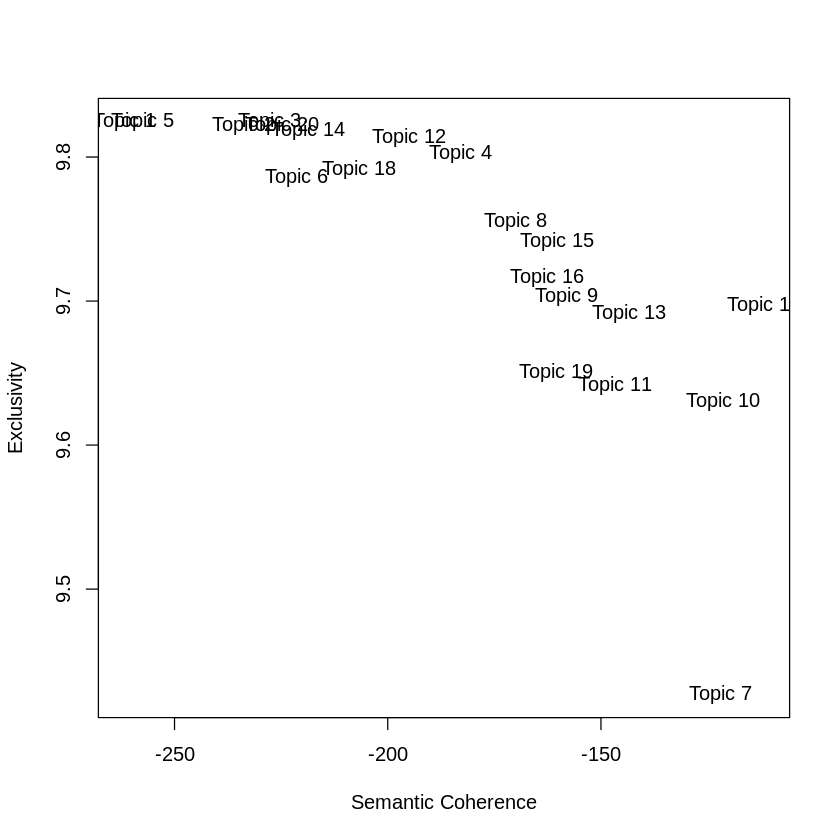

In [67]:




# The topicQuality() function plots these values
# and labels each with its topic number:

topicQuality(model=Third_STM, documents=docs)

## VODAFONE'S **output**

In [68]:
# Clear up data in global environment
rm(list=ls())

# Load data from csv file
df <- read.csv("Vodafone_Comments.csv")

# Check for NAs
sapply(df, function(x) sum(is.na(x)))

# Overview of original dataset
str(df)
sapply(df, typeof)

X   Comment   Website Sentiment   company 
        0         0         0         0         0

'data.frame':	408 obs. of  5 variables:
 $ X        : int  0 1 2 3 4 5 6 7 8 9 ...
 $ Comment  : chr  "If 5G becomes unlimited in the future, it will be useful. If speed is provided according to the price, then it should be less" "They might bring unlimited internet plans with around ₹999/- per month charges or so! The price might be much h"| __truncated__ "I think you don’t follow the latest trends. I live in a Tier 2 city and have had fiber connectivity here for th"| __truncated__ "5G is not fully ready, but it’s ready to be fast.  I haven't received it in my area yet" ...
 $ Website  : chr  "youtube" "youtube" "youtube" "youtube" ...
 $ Sentiment: int  1 1 1 -1 1 -1 1 1 1 1 ...
 $ company  : chr  "Vodafone" "Vodafone" "Vodafone" "Vodafone" ...


X     Comment     Website   Sentiment     company 
  "integer" "character" "character"   "integer" "character"

In [69]:


df[sample(nrow(df), 10), ]

,X,Comment,Website,Sentiment,company
,<int>,<chr>,<chr>,<int>,<chr>
130,129,"RT ESL: RT ESLPUBGMobile: Smokes, cars and chicken dinners aplenty.... Q3 of the Vodafone 5G #ESLMobileOpen June Cup was pure 🔥. verdipwnz takes us through this week's top plays! https://t.co/YI9jVT77bc",twitter,1,Vodafone
262,261,@LewisHamilton @VodafoneUK How about moving back to the Uk. You would be amazed at the welcome for you,twitter,1,Vodafone
11,10,"Seriously, my VI's 4G is better than that.",youtube,1,Vodafone
117,116,"🇪🇸#Spain's first commercial #5G 📱 network is set to be launched by #Vodafone Spain in collaboration with #Huawei on Sat. The service will cover 15 cities such as Madrid, Barcelona, Valencia, Seville, Malaga, Zaragoza, Bilbao, Vitoria etc. https://t.co/oHY5GVRUo9",twitter,-1,Vodafone
276,275,@LewisHamilton @VodafoneUK Great to hear as a Vodafone customer...!!,twitter,1,Vodafone
257,256,@LewisHamilton @VodafoneUK You must need the money Lewis,twitter,-1,Vodafone
342,341,@VodafoneUK Fab chance #Vodafone5Golds 🥇,twitter,-1,Vodafone
379,378,@VodafoneUK #Vodafone5Golds,twitter,-1,Vodafone
400,399,"5G speeds are fantastic for browsing, but the connection drops indoors sometimes.",survey,-1,Vodafone


In [70]:
# Install necessary packages if not already installed
install.packages("stm")
install.packages("tm")
install.packages("SnowballC")

# Load required libraries
library(tm)
library(SnowballC)
library(stm)

# Load the dataset
df <- read.csv("Vodafone_Comments.csv")

# Perform text processing on the 'Comment' column
processed <- textProcessor(df$Comment, metadata = df,
                           lowercase = TRUE,           # Convert to lowercase
                           removestopwords = TRUE,     # Remove stop words
                           removenumbers = TRUE,       # Remove numbers
                           removepunctuation = TRUE,   # Remove punctuation
                           stem = TRUE,                # Apply stemming
                           wordLengths = c(3, Inf),    # Keep words of length 3 or more
                           sparselevel = 1,            # Keep all words (no sparsity cutoff)
                           language = "en",            # English language
                           verbose = TRUE,             # Display detailed output
                           onlycharacter = TRUE,       # Keep only alphabetic characters
                           striphtml = FALSE,          # Do not remove HTML tags (no HTML in the data)
                           customstopwords = NULL,     # No custom stopwords
                           v1 = FALSE)                 # Use the default version of textProcessor

# Output the result of the text processing
str(processed)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Building corpus... 
Converting to Lower Case... 
Removing punctuation... 
Removing stopwords... 
Removing numbers... 
Stemming... 
Creating Output... 
List of 4
 $ documents   :List of 408
  ..$ 1  : int [1:2, 1:10] 3 1 99 1 586 1 800 1 1093 1 ...
  ..$ 2  : int [1:2, 1:13] 63 1 129 2 177 1 675 1 731 1 ...
  ..$ 3  : int [1:2, 1:15] 188 1 282 2 445 1 560 1 571 1 ...
  ..$ 4  : int [1:2, 1:7] 62 1 551 1 584 1 663 1 1146 2 ...
  ..$ 5  : int [1:2, 1:6] 398 1 531 1 965 1 1332 1 1578 1 ...
  ..$ 6  : int [1:2, 1:6] 83 1 92 1 524 1 697 1 1037 1 ...
  ..$ 7  : int [1:2, 1:40] 1 1 33 1 62 1 67 1 83 1 ...
  ..$ 8  : int [1:2, 1:10] 83 1 87 1 145 1 915 2 959 1 ...
  ..$ 9  : int [1:2, 1:6] 87 1 260 1 570 1 919 1 1467 1 ...
  ..$ 10 : int [1:2, 1:12] 33 1 190 1 807 1 1040 1 1046 1 ...
  ..$ 11 : int [1:2, 1:3] 108 1 1255 1 1525 1
  ..$ 12 : int [1:2, 1:4] 107 1 133 1 560 1 1013 1
  ..$ 13 : int [1:2, 1:8] 88 1 107 1 180 1 373 1 999 1 ...
  ..$ 14 : int [1:2, 1:7] 88 1 616 1 718 1 985 1 1326 1 ..

In [71]:
# Load required library
library(stm)

# Assuming 'df' is already loaded and 'processed' contains the text processed data
# If not, load the data and process it using textProcessor as described earlier

# Filter out terms that don’t appear in more than 10 documents
out <- prepDocuments(processed$documents, processed$vocab, processed$meta, lower.thresh=5)

# Extract documents, vocab, and metadata after filtering
docs <- out$documents
vocab <- out$vocab
meta <- out$meta



Removing 1530 of 1632 terms (2231 of 3911 tokens) due to frequency 
Removing 4 Documents with No Words 
Your corpus now has 404 documents, 102 terms and 1680 tokens.

In [72]:
str(meta)
# Convert 'Website' and 'company' to factors if they are not already
meta$Website <- as.factor(meta$Website)
meta$company <- as.factor(meta$company)

# Check levels of categorical variables in 'meta'
# Assuming 'Website' and 'company' are the categorical variables
levels(meta$Website)
levels(meta$company)


'data.frame':	404 obs. of  5 variables:
 $ X        : int  0 1 2 3 4 5 6 7 8 9 ...
 $ Comment  : chr  "If 5G becomes unlimited in the future, it will be useful. If speed is provided according to the price, then it should be less" "They might bring unlimited internet plans with around ₹999/- per month charges or so! The price might be much h"| __truncated__ "I think you don’t follow the latest trends. I live in a Tier 2 city and have had fiber connectivity here for th"| __truncated__ "5G is not fully ready, but it’s ready to be fast.  I haven't received it in my area yet" ...
 $ Website  : chr  "youtube" "youtube" "youtube" "youtube" ...
 $ Sentiment: int  1 1 1 -1 1 -1 1 1 1 1 ...
 $ company  : chr  "Vodafone" "Vodafone" "Vodafone" "Vodafone" ...


[1] "instagram" "survey"    "twitter"   "youtube"

[1] "Vodafone"

Beginning Spectral Initialization 
	 Calculating the gram matrix...
	 Finding anchor words...
 	...............
	 Recovering initialization...
 	.
Initialization complete.
.....................................................................................................
Completed E-Step (0 seconds). 
Completed M-Step. 
Completing Iteration 1 (approx. per word bound = -4.627) 
.....................................................................................................
Completed E-Step (0 seconds). 
Completed M-Step. 
Completing Iteration 2 (approx. per word bound = -4.260, relative change = 7.937e-02) 
.....................................................................................................
Completed E-Step (0 seconds). 
Completed M-Step. 
Completing Iteration 3 (approx. per word bound = -4.047, relative change = 5.008e-02) 
.....................................................................................................
Completed E-Step (0 seconds). 
Complet

   user  system elapsed 
  0.995   0.004   0.998 

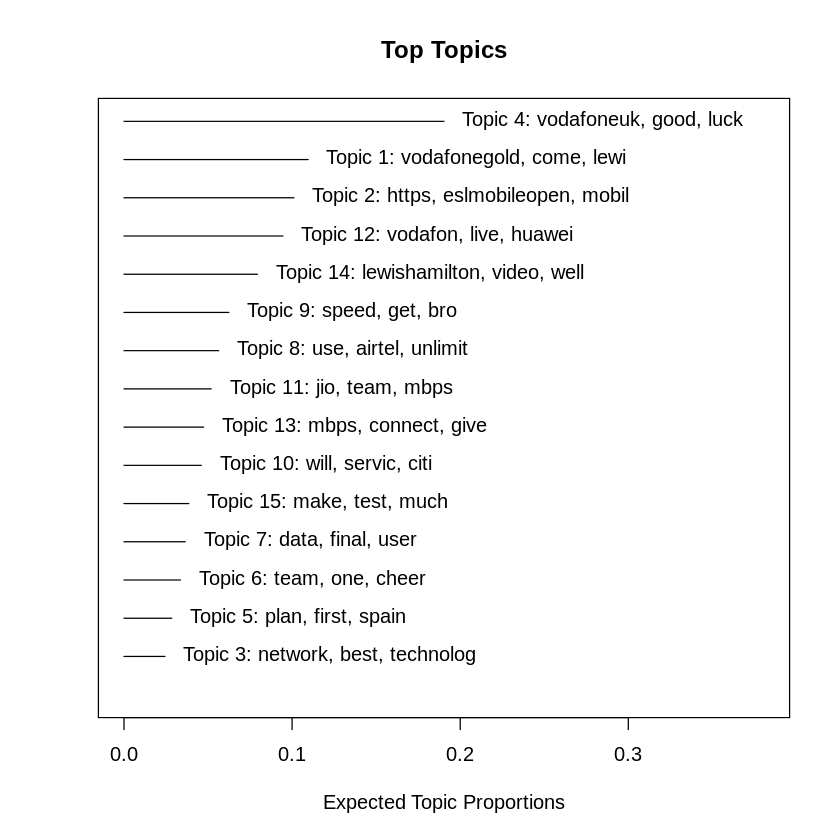

In [73]:
# Try with just 'company' as the prevalence variable
system.time({
  First_STM <- stm(docs, vocab, 15,
                   prevalence =~ Website,  # Use only one covariate for now
                   data = meta,
                   seed = 15, max.em.its = 5
  )
})

plot(First_STM)


   user  system elapsed 
 10.463   0.000  10.465 

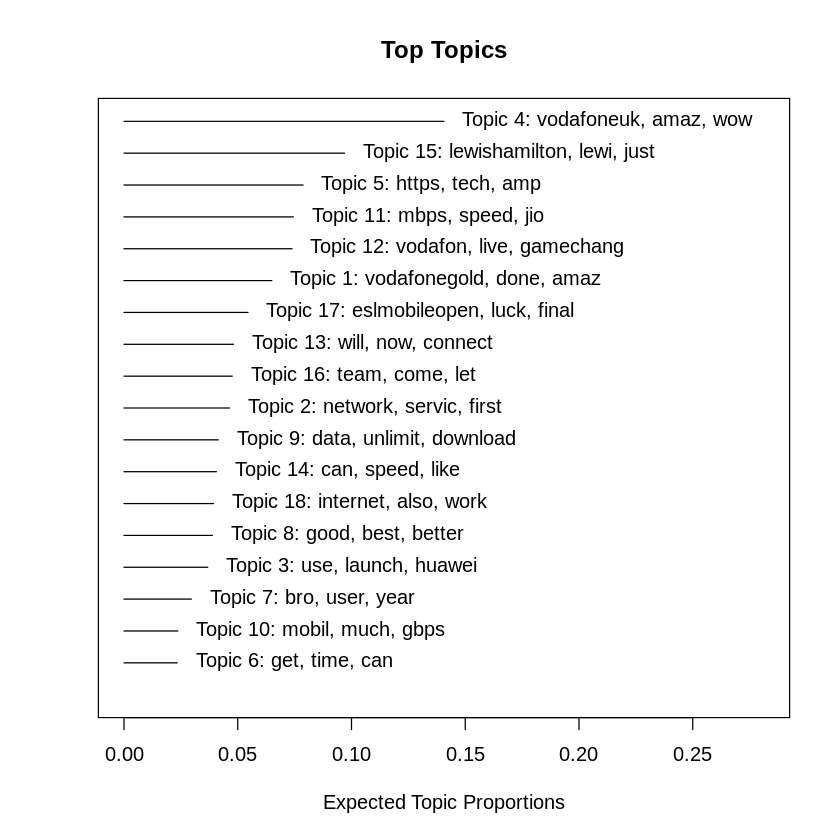

In [74]:
# Load required library
library(stm)

# Set seed for reproducibility
set.seed(832)

# Perform the second STM with 18 topics and a maximum of 75 EM iterations
system.time({
  Second_STM <- stm(documents = out$documents,
                    vocab = out$vocab,
                    K = 18,
                    prevalence =~  Website,  # Adjust this to match your actual data columns
                    max.em.its = 75,
                    data = out$meta,
                    init.type = "Spectral",
                    verbose = FALSE
  )
})

# Plot the second topic model
plot(Second_STM)


   user  system elapsed 
106.173   0.012 106.199 

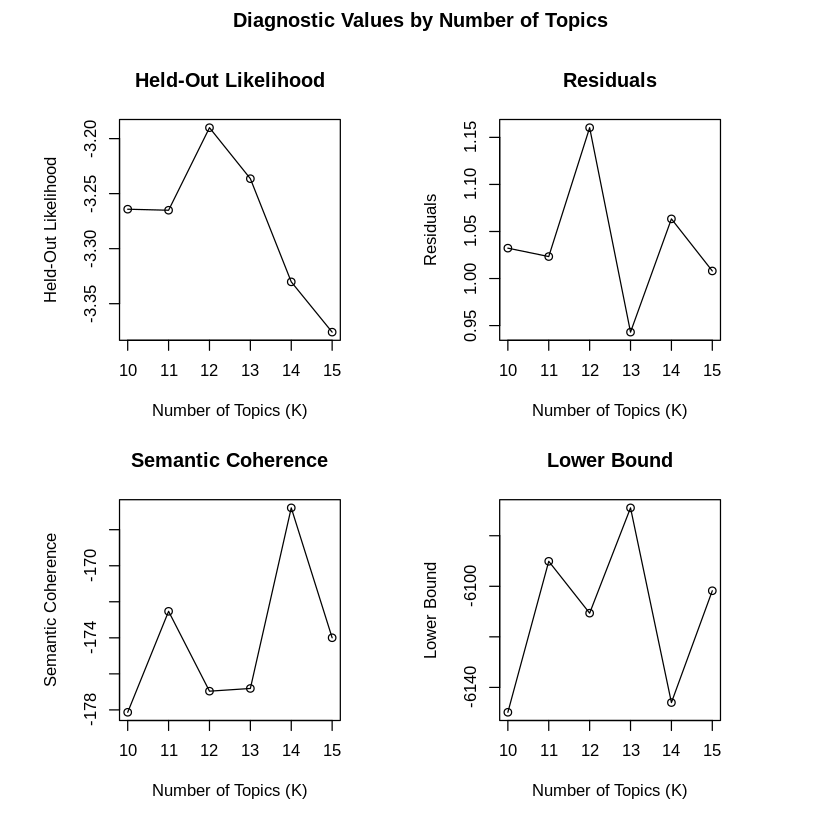

In [75]:
# Load required library
library(stm)

# Set seed for reproducibility
set.seed(833)

# Find the optimal number of topics from 10 to 30
system.time({
    findingk <- searchK(out$documents,
                         out$vocab,
                         K = 10:15,           # Range of topics to test
                         prevalence =~  Website, # Adjust to your metadata
                         data = out$meta,
                         verbose = FALSE
    )
})

# Plot the results to visualize the optimal k
plot(findingk)

Beginning Spectral Initialization 
	 Calculating the gram matrix...
	 Finding anchor words...
 	..........
	 Recovering initialization...
 	.
Initialization complete.
.....................................................................................................
Completed E-Step (0 seconds). 
Completed M-Step. 
Completing Iteration 1 (approx. per word bound = -4.824) 
.....................................................................................................
Completed E-Step (0 seconds). 
Completed M-Step. 
Completing Iteration 2 (approx. per word bound = -4.380, relative change = 9.192e-02) 
.....................................................................................................
Completed E-Step (0 seconds). 
Completed M-Step. 
Completing Iteration 3 (approx. per word bound = -4.197, relative change = 4.187e-02) 
.....................................................................................................
Completed E-Step (0 seconds). 
Completed M-

   user  system elapsed 
112.870   0.574 113.460 

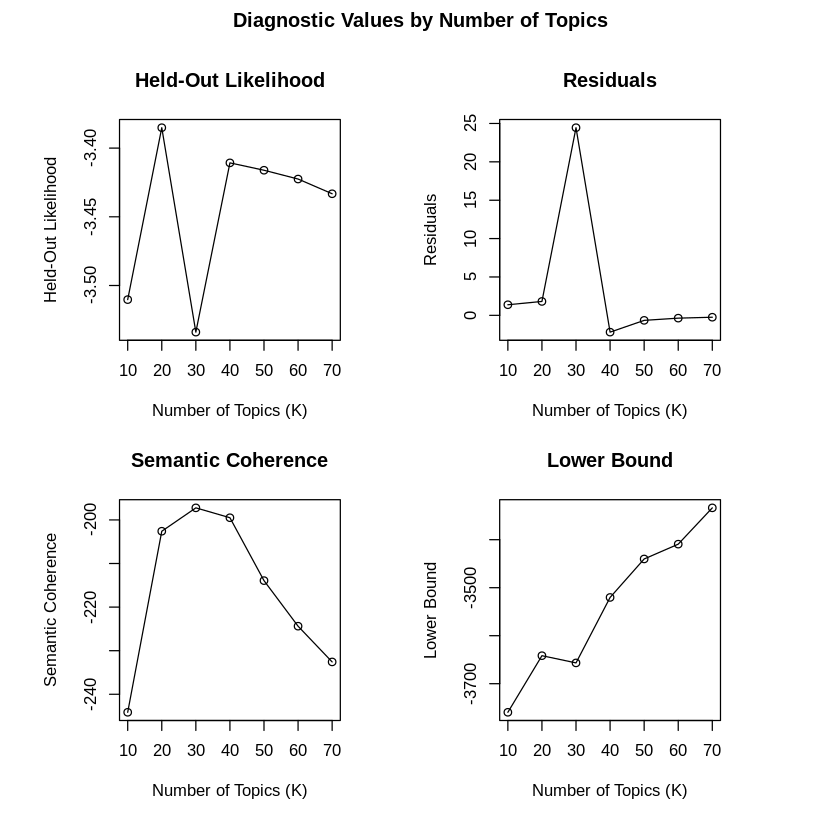

In [79]:
# Load required library
library(stm)

# Set seed for reproducibility
set.seed(834)

# Find the optimal number of topics with specific parameters
system.time({
    findingk_ver2 <- searchK(documents = out$documents,
                              vocab = out$vocab,
                              K = c(10, 20, 30, 40, 50, 60, 70), # Specify K to try
                              N = 400,  # Matches 10% of documents, adjust if needed
                              proportion = 0.5, # Default proportion of heldout data
                              heldout.seed = 1234, # Optional seed for reproducibility
                              M = 10, # Number of heldout iterations
                              cores = 1, # Number of cores to use (default = 1)
                              prevalence =~  Website, # Adjust based on your metadata
                              max.em.its = 75, # Maximum EM iterations
                              data = out$meta, # Metadata
                              init.type = "Spectral", # Initialization method
                              verbose = TRUE # Verbose output
    )
})

# Plot the results to visualize the optimal k
plot(findingk_ver2)


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Beginning Spectral Initialization 
	 Calculating the gram matrix...
	 Finding anchor words...
 		 Initializing tSNE with PCA...
 		 Using tSNE to project to a low-dimensional space...
 		 Calculating exact convex hull...
 	
	 Recovering initialization...
 	.
Initialization complete.
.....................................................................................................
Completed E-Step (0 seconds). 
Completed M-Step. 
Completing Iteration 1 (approx. per word bound = -4.640) 
.....................................................................................................
Completed E-Step (0 seconds). 
Completed M-Step. 
Completing Iteration 2 (approx. per word bound = -4.218, relative change = 9.092e-02) 
.....................................................................................................
Completed E-Step (0 seconds). 
Completed M-Step. 
Completing Iteration 3 (approx. per word bound = -4.020, relative change = 4.685e-02) 
............................

   user  system elapsed 
 14.111   0.102  14.215 

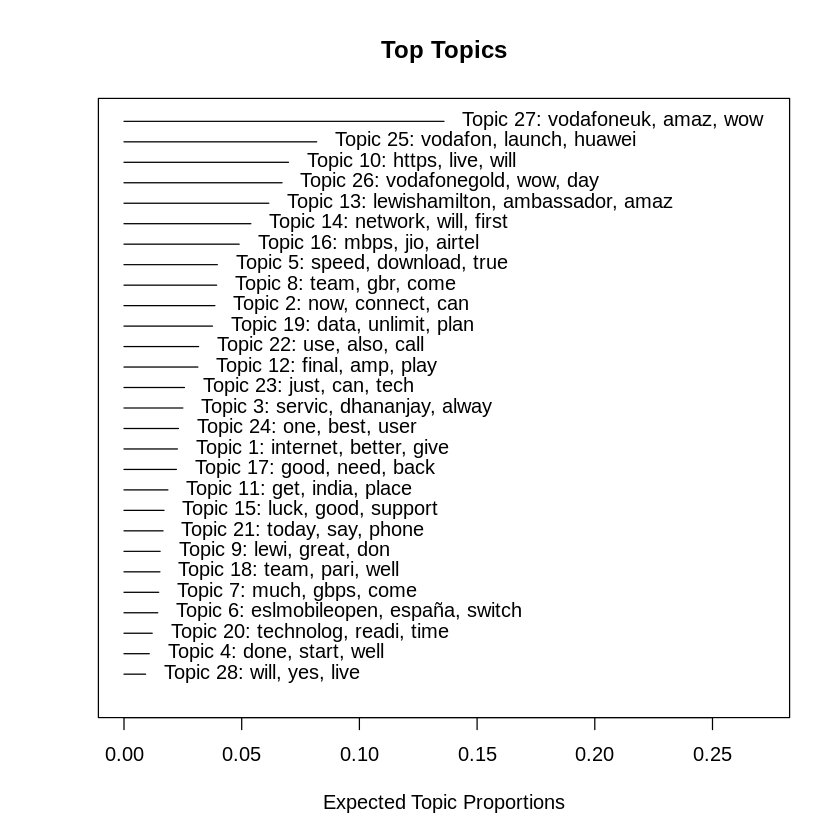

In [80]:
# Load required library
install.packages(c("Rtsne", "rsvd", "geometry"))
library(Rtsne)
library(rsvd)
library(geometry)
library(stm)

# Set seed for reproducibility
set.seed(835)

# Find the optimal number of topics using the Lee-Mimno method
system.time({
    findingk_ver3.lee_mimno <- stm(documents = out$documents,
                                    vocab = out$vocab,
                                    K = 0,  # K=0 to run the Lee-Mimno method
                                    seed = 1234,  # Seed for reproducibility
                                    prevalence =~  Website,  # Adjust this based on your metadata
                                    max.em.its = 75,  # Maximum EM iterations
                                    data = out$meta,  # Metadata
                                    init.type = "Spectral",  # Initialization method
                                    verbose = TRUE  # Verbose output
    )
})

# Plot the results to visualize the optimal k
plot(findingk_ver3.lee_mimno)


   user  system elapsed 
 11.064   0.002  11.067 

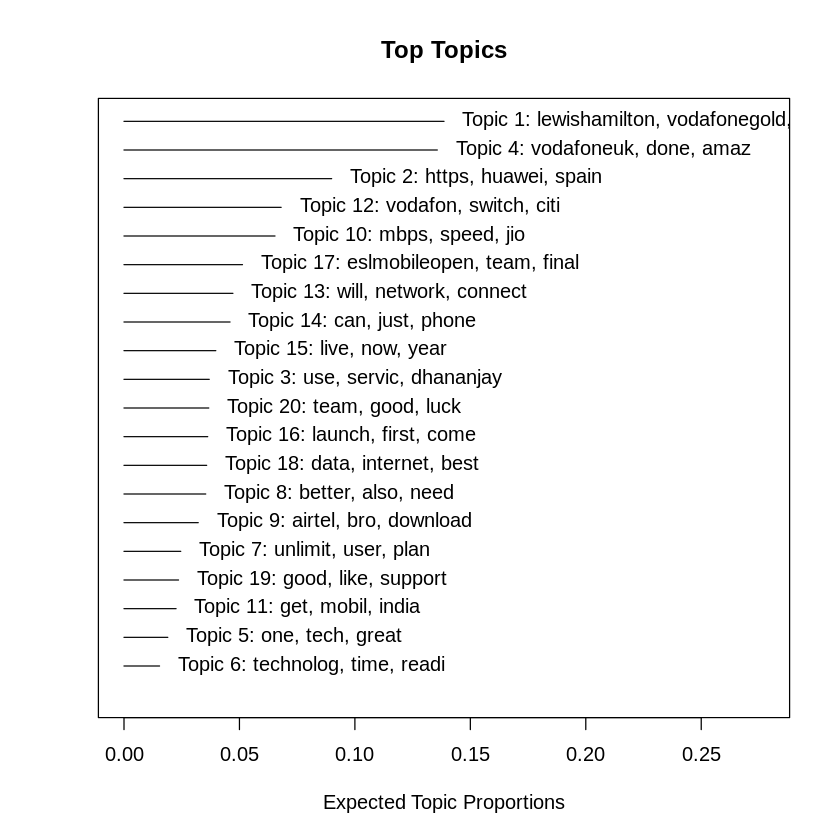

In [81]:
# Run final topic model at 20 topics and see how long it takes
set.seed(836)
system.time({
    Third_STM <- stm(documents = out$documents, vocab = out$vocab,
                  K = 20, prevalence =~  Website,
                  max.em.its = 75, data = out$meta,
                  init.type = "Spectral", verbose = FALSE
    )
})

#Plot
plot(Third_STM)

In [82]:
# Top Words
labelTopics(Third_STM)

Topic 1 Top Words:
 	 Highest Prob: lewishamilton, vodafonegold, lewi, wow, amaz, come, pleas 
 	 FREX: lewishamilton, vodafonegold, lewi, wow, come, make, day 
 	 Lift: lewishamilton, vodafonegold, lewi, wow, amaz, come, pleas 
 	 Score: vodafonegold, lewishamilton, lewi, wow, amaz, come, pleas 
Topic 2 Top Words:
 	 Highest Prob: https, huawei, spain, amp, españa, wow, test 
 	 FREX: https, spain, huawei, españa, amp, wow, switch 
 	 Lift: españa, spain, https, huawei, amp, wow, test 
 	 Score: https, españa, huawei, spain, amp, wow, test 
Topic 3 Top Words:
 	 Highest Prob: use, servic, dhananjay, plan, year, launch, spain 
 	 FREX: servic, dhananjay, use, plan, citi, huawei, alway 
 	 Lift: dhananjay, use, servic, plan, year, launch, spain 
 	 Score: dhananjay, servic, use, plan, year, launch, spain 
Topic 4 Top Words:
 	 Highest Prob: vodafoneuk, done, amaz, come, lewi, bro, pleas 
 	 FREX: vodafoneuk, done, amaz, wow, come, make, don 
 	 Lift: vodafoneuk, done, amaz, come, lewi, 

In [83]:
# We can find the top documents associated with a topic with the findThoughts function:
# top 2 paragraps for Topic 1 to 10

findThoughts(Third_STM, texts = meta$Comment,n = 2, topics = 1:10)


 Topic 1: 
 	 @LewisHamilton @VodafoneUK 5G IS A HEALTH AND SAFETY NIGHTMARE. DO A BIT OF RESEARCH LEWIS.
 	@LewisHamilton @VodafoneUK Wow cancer rates to rise.......#5G 
 Topic 2: 
 	 #5G-Technologie macht's möglich: Noemi Ristau ist sehbehindert &amp; fährt trotzdem jede Skipiste runter. Jetzt konnte sie erstmals alleine fahren. Wow! Wie sie das gemacht hat &amp; was das mit @vodafone_de zu tun hat? Erlebt es selbst. Mich hat es sehr berührt. https://t.co/CrQOIIcRtS https://t.co/5ljUq9OYZc
 	Vodafone lanza primera red 5G en España https://t.co/YJApEpzAdT https://t.co/UpGFi4Wu6R 
 Topic 3: 
 	 Service is okay, but not exceptional.
 	Service is solid. 
 Topic 4: 
 	 @VodafoneUK Soooo proud of each and every athlete 🥹 they've done us all so so proud! Roll on LA 🥇🥇🥇🥇🥇 #Vodafone5golds
 	@LewisHamilton @VodafoneUK Think you should have done a little more research on this before you put your name to it! 
 Topic 5: 
 	 Vodafone's site for 5G launch day at Sky Garden. Ericsson AIR6488 5G Mas

In [84]:
# We can find the top documents associated with a topic with the findThoughts function:
# top 2 paragraps for Topic 1 to 10

findThoughts(Third_STM, texts = meta$Comment,n = 3, topics = 1:15)


 Topic 1: 
 	 @LewisHamilton @VodafoneUK 5G IS A HEALTH AND SAFETY NIGHTMARE. DO A BIT OF RESEARCH LEWIS.
 	@LewisHamilton @VodafoneUK Wow cancer rates to rise.......#5G
 	@VodafoneUK Wow #vodafone5golds 
 Topic 2: 
 	 #5G-Technologie macht's möglich: Noemi Ristau ist sehbehindert &amp; fährt trotzdem jede Skipiste runter. Jetzt konnte sie erstmals alleine fahren. Wow! Wie sie das gemacht hat &amp; was das mit @vodafone_de zu tun hat? Erlebt es selbst. Mich hat es sehr berührt. https://t.co/CrQOIIcRtS https://t.co/5ljUq9OYZc
 	Vodafone lanza primera red 5G en España https://t.co/YJApEpzAdT https://t.co/UpGFi4Wu6R
 	LG V50 ThinQ 5G llega a España gracias a Vodafone https://t.co/Y9gZ7J5Cil https://t.co/PGDhSnH9Bp 
 Topic 3: 
 	 Service is okay, but not exceptional.
 	Service is solid.
 	Service is excellent. 
 Topic 4: 
 	 @VodafoneUK Soooo proud of each and every athlete 🥹 they've done us all so so proud! Roll on LA 🥇🥇🥇🥇🥇 #Vodafone5golds
 	@LewisHamilton @VodafoneUK Think you should ha

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



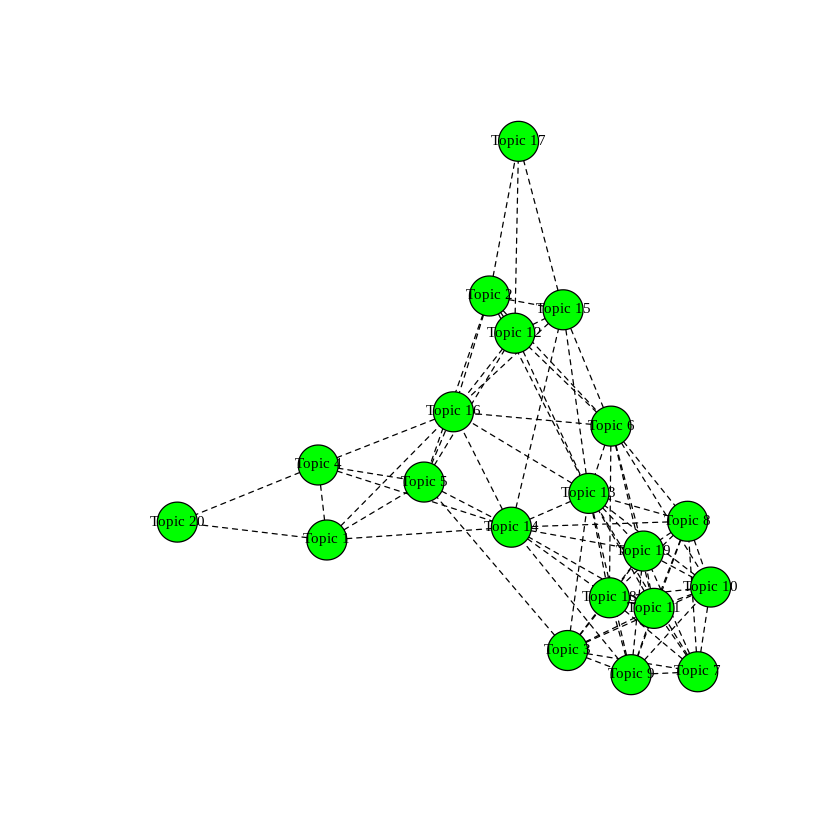

In [85]:

# Graphical display of topic correlations
install.packages("igraph")
library(igraph)

topic_correlation<-topicCorr(Third_STM)
plot(topic_correlation)

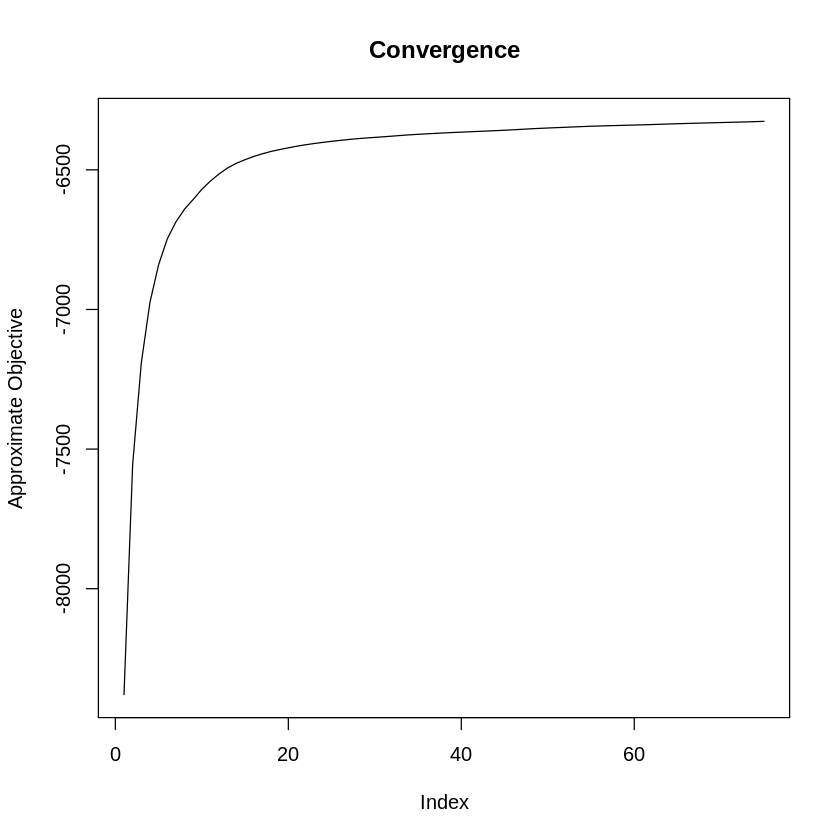

In [86]:
# Graphical display of convergence


plot(Third_STM$convergence$bound, type = "l",
         ylab = "Approximate Objective",
         main = "Convergence")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message in wordcloud::wordcloud(words = vocab, freq = vec, max.words = max.words, :
“medal could not be fit on page. It will not be plotted.”
Warning message in wordcloud::wordcloud(words = vocab, freq = vec, max.words = max.words, :
“next could not be fit on page. It will not be plotted.”
Warning message in wordcloud::wordcloud(words = vocab, freq = vec, max.words = max.words, :
“final could not be fit on page. It will not be plotted.”
Warning message in wordcloud::wordcloud(words = vocab, freq = vec, max.words = max.words, :
“eslmobileopen could not be fit on page. It will not be plotted.”
Warning message in wordcloud::wordcloud(words = vocab, freq = vec, max.words = max.words, :
“come could not be fit on page. It will not be plotted.”


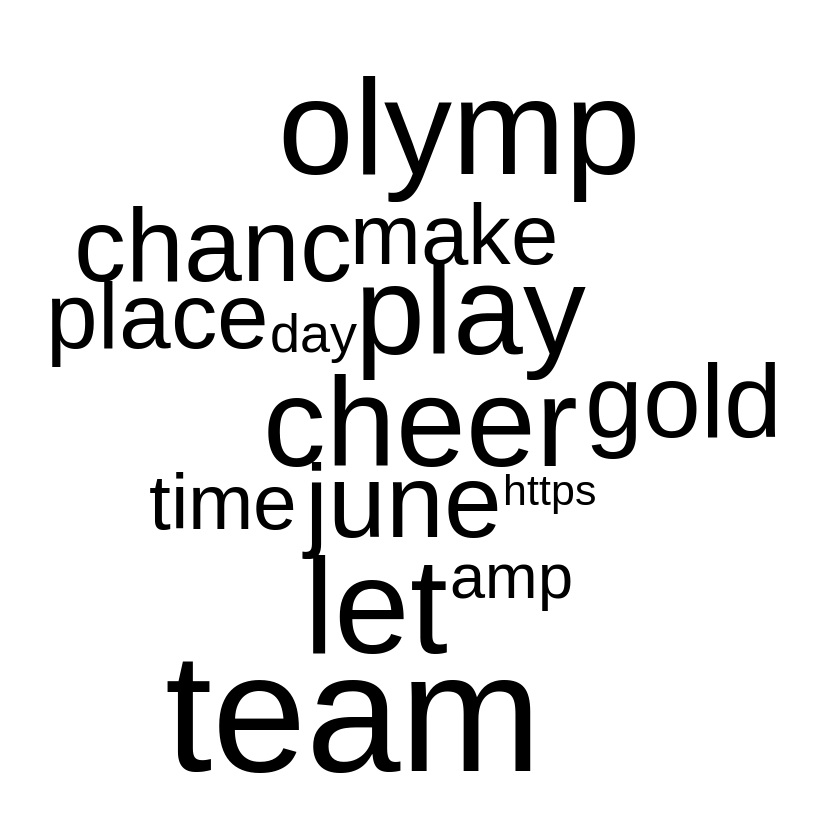

In [87]:

# Wordcloud:topic 17 with word distribution
install.packages("wordcloud")
library(wordcloud)

set.seed(837)
cloud(Third_STM, topic=17, scale=c(10,2))

In [88]:
print(Third_STM$settings$dim$K)


[1] 20


In [89]:



predict_topics <- estimateEffect(
  formula = 1:10 ~ Website,  # Using 'Website' for now
  stmobj = Third_STM,        # Ensure 'Third_STM' exists
  metadata = out$meta,
  uncertainty = "Global"
)

str(predict_topics)

List of 8
 $ parameters :List of 10
  ..$ :List of 25
  .. ..$ :List of 2
  .. .. ..$ est : Named num [1:4] 0.0075 -0.00641 0.15213 -0.00564
  .. .. .. ..- attr(*, "names")= chr [1:4] "(Intercept)" "Websitesurvey" "Websitetwitter" "Websiteyoutube"
  .. .. ..$ vcov: num [1:4, 1:4] 0.000399 -0.000399 -0.000399 -0.000399 -0.000399 ...
  .. ..$ :List of 2
  .. .. ..$ est : Named num [1:4] 0.00851 -0.00751 0.14672 -0.00607
  .. .. .. ..- attr(*, "names")= chr [1:4] "(Intercept)" "Websitesurvey" "Websitetwitter" "Websiteyoutube"
  .. .. ..$ vcov: num [1:4, 1:4] 0.00042 -0.00042 -0.00042 -0.00042 -0.00042 ...
  .. ..$ :List of 2
  .. .. ..$ est : Named num [1:4] 0.01068 -0.0095 0.14341 -0.00858
  .. .. .. ..- attr(*, "names")= chr [1:4] "(Intercept)" "Websitesurvey" "Websitetwitter" "Websiteyoutube"
  .. .. ..$ vcov: num [1:4, 1:4] 0.000419 -0.000419 -0.000419 -0.000419 -0.000419 ...
  .. ..$ :List of 2
  .. .. ..$ est : Named num [1:4] 0.00901 -0.00801 0.14546 -0.00664
  .. .. .. ..- attr(*,

[1] "X"         "Comment"   "Website"   "Sentiment" "company"  


[1] "instagram" "survey"    "twitter"   "youtube"

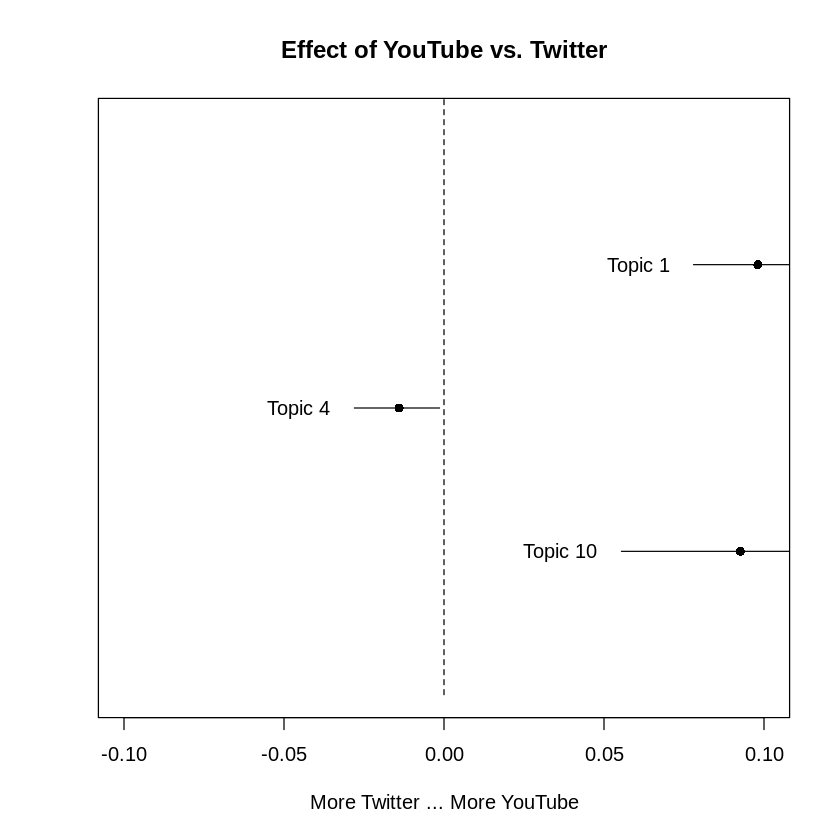

In [97]:



# Check metadata column names


print(names(out$meta))

# Ensure 'Website' is a factor
out$meta$Website <- as.factor(out$meta$Website)

# Estimate effect of 'Website' covariate on topics
predict_topics <- estimateEffect(formula = 1:10 ~ Website,   # Only 'Website' is used
                                 stmobj = Third_STM,
                                 metadata = out$meta,
                                 uncertainty = "Global",
                                 prior = 1e-5)

# Check levels of 'Website' to ensure valid covariate values
levels(out$meta$Website)

# Set seed for reproducibility
set.seed(837)

# Plot the effect of 'Website' covariate on selected topics
plot(predict_topics,
     covariate = "Website",
     topics = c(9, 5, 7),              # Topics of interest
     model = Third_STM,
     method = "difference",
     cov.value1 = "youtube",           # Change to actual levels in your data
     cov.value2 = "twitter",           # Compare two levels in 'Website'
     xlab = "More Twitter ... More YouTube",
     main = "Effect of YouTube vs. Twitter",
     xlim = c(-0.1, 0.1),
     labeltype = "custom",
     custom.labels = c('Topic 1', 'Topic 4', 'Topic 10'))


[1] "instagram" "survey"    "twitter"   "youtube"

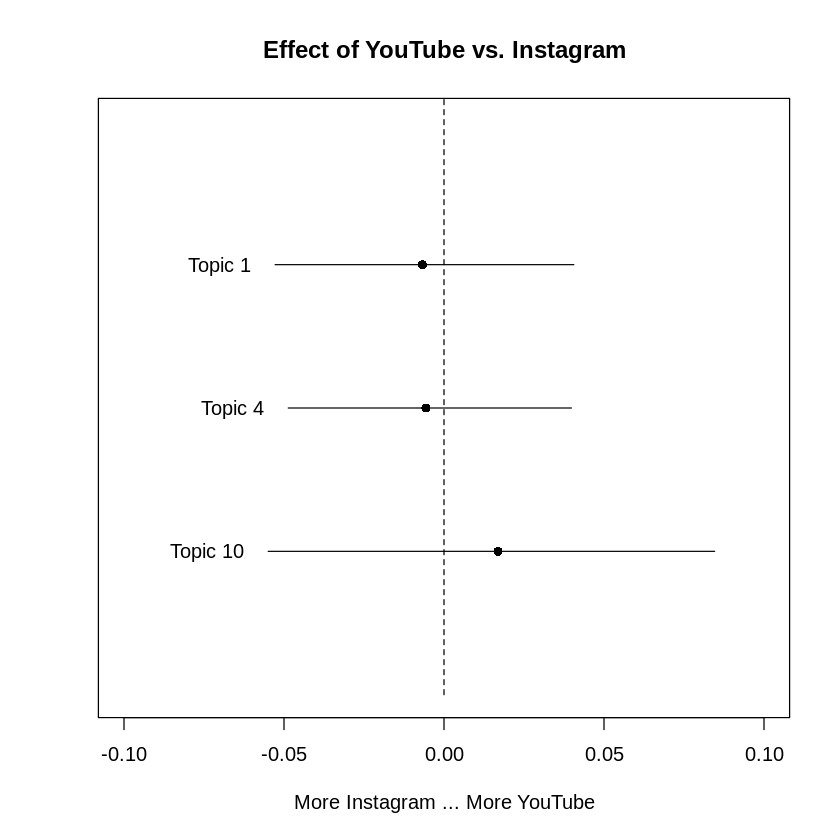

In [92]:







# Check the levels of the 'Website' variable
levels(out$meta$Website)  # Ensure 'youtube' and 'instagram' are valid levels

# Ensure the covariate values are valid levels
set.seed(837)
plot(predict_topics,
     covariate = "Website",            # Focus on 'Website' covariate
     topics = c(1, 4, 10),             # Topics of interest
     model = Third_STM,
     method = "difference",
     cov.value1 = "youtube",           # Compare 'YouTube'
     cov.value2 = "instagram",         # With 'Instagram'
     xlab = "More Instagram ... More YouTube",
     main = "Effect of YouTube vs. Instagram",   # Updated plot title
     xlim = c(-0.1, 0.1),
     labeltype = "custom",
     custom.labels = c('Topic 1', 'Topic 4', 'Topic 10'))


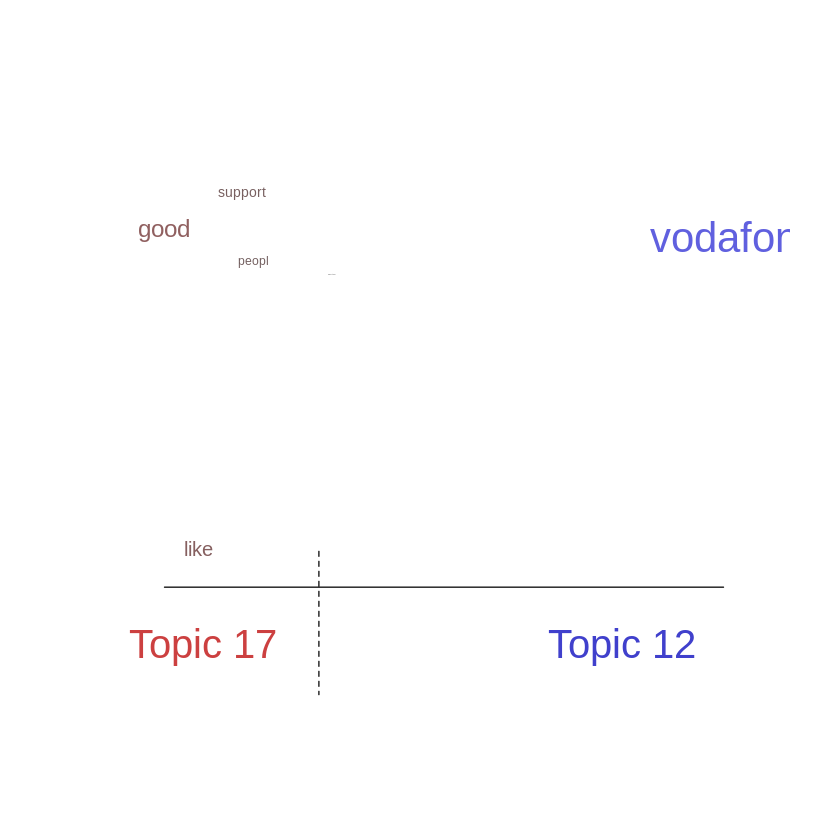

In [107]:

set.seed(831)
plot(Third_STM,
     type="perspectives",
     topics=c(19,12),
     plabels = c("Topic 19","Topic 12"))

[1] 20


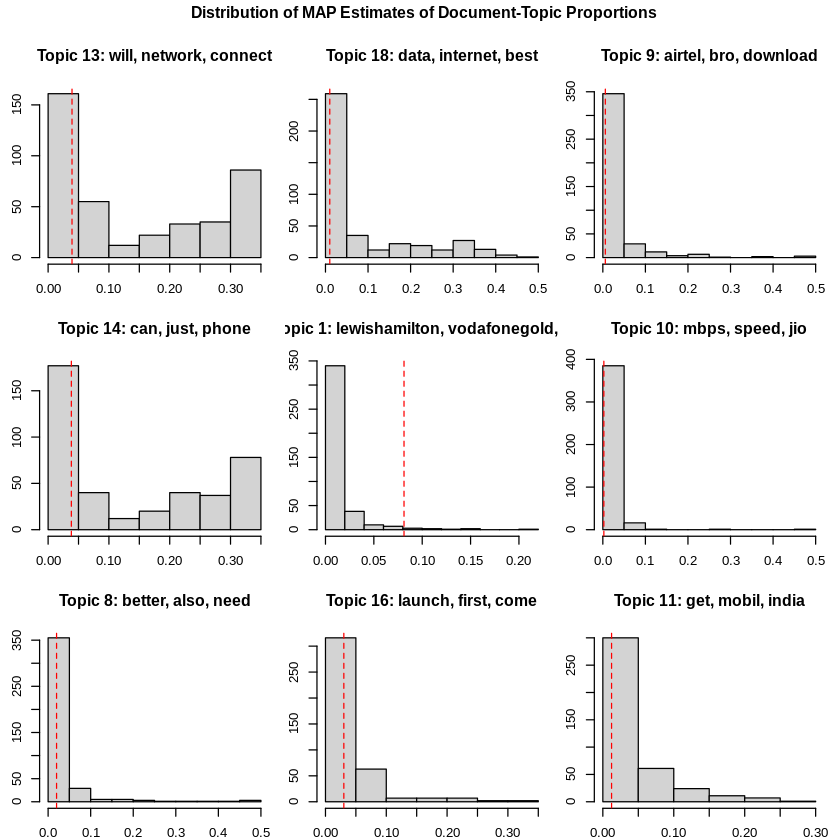

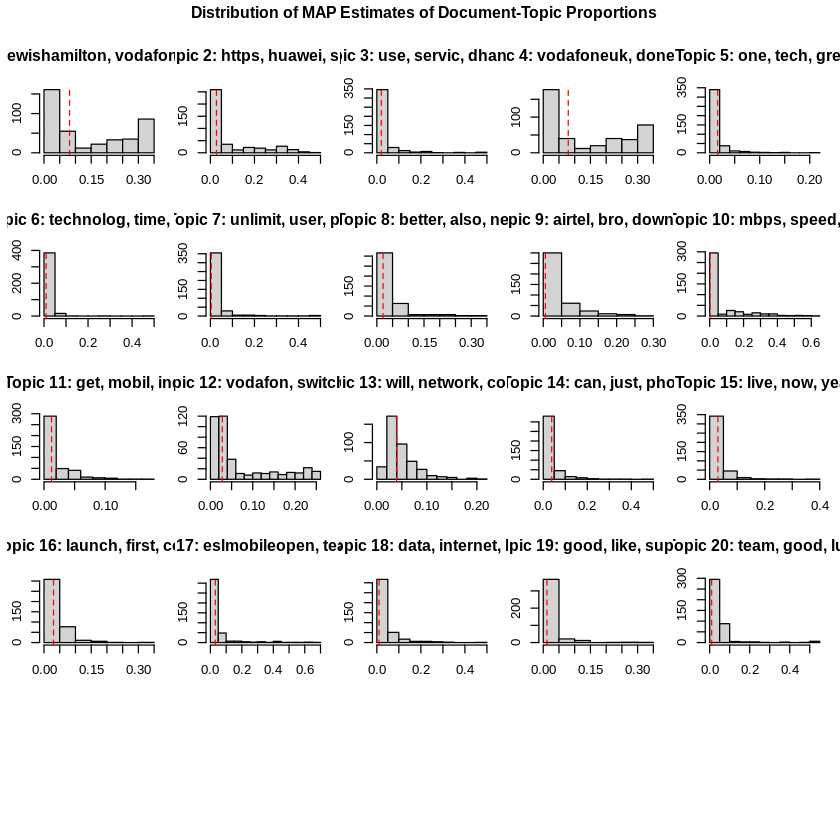

In [94]:

print(Third_STM$settings$dim$K)



predict_topics <- estimateEffect(
  formula = 1:10 ~ Website,  # Using 'Website' for now
  stmobj = Third_STM,        # Ensure 'Third_STM' exists
  metadata = out$meta,
  uncertainty = "Global"
)





# Topic proportions

plot(Third_STM, type = "hist", topics = sample(1:20, size = 9))
plot(Third_STM, type="hist")

 [1] -231.5210 -214.0207 -162.2040 -187.3064 -172.0034 -141.5322 -160.5353
 [8] -163.4436 -148.5215 -141.9158 -215.3254 -153.8538 -197.9431 -133.9028
[15] -193.7246 -191.4493 -130.5541 -108.0419 -200.0847 -165.1225
 [1] 9.558783 9.558287 9.558660 9.558770 9.558696 9.558456 9.558657 9.557669
 [9] 9.558445 9.558454 9.558701 9.551939 9.558286 9.557327 9.556391 9.557031
[17] 9.380816 9.558093 9.558568 9.558175


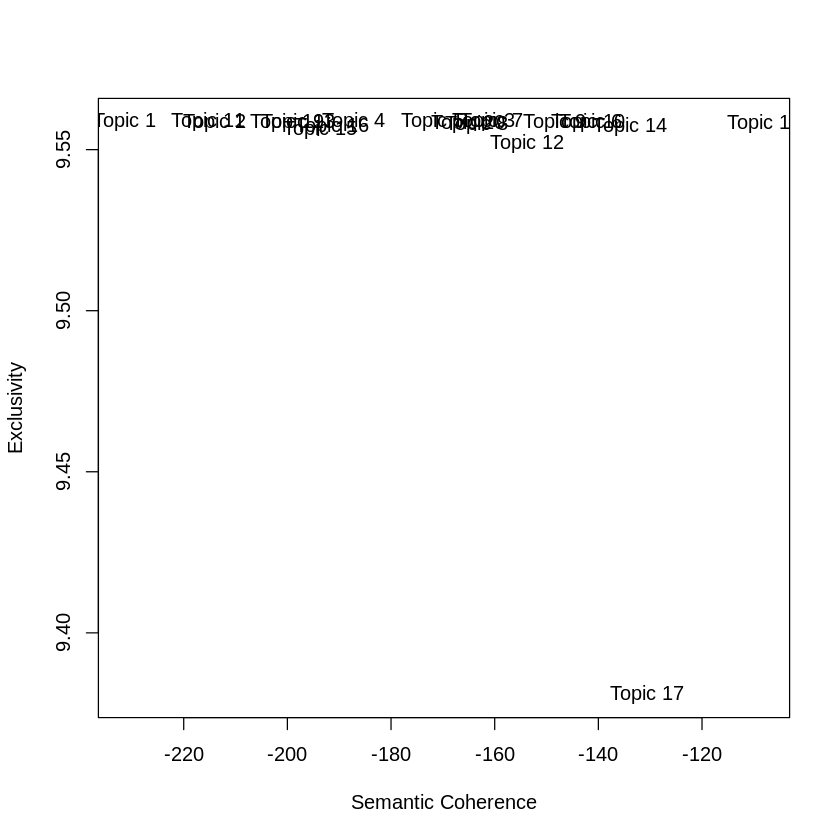

In [95]:


# The topicQuality() function plots these values
# and labels each with its topic number:

topicQuality(model=Third_STM, documents=docs)